# SWH-JB-GRT — Kebutuhan Air, Debit, dan Water Loss per Petak

Lanjutan dari [`note-swh-jb_grt.ipynb`](note-swh-jb_grt.ipynb) yang baru menjawab terrain
dan luas. Notebook ini menjawab tiga hal berikutnya:

1. **Berapa kebutuhan air** tiap petak — dalam mm dan m³
2. **Berapa debit** yang harus mengalir, dan seberapa besar pintunya
3. **Berapa water loss** — menguap, meresap, mengalir keluar — beserta **persennya**

### Sumber angka

| Apa | Dari mana | Sifat |
|---|---|---|
| Batas & luas petak | `note-swh-jb_grt.ipynb` → `output-swh-jb-grt/` | diukur dari KML |
| Cuaca harian 11 tahun | Open-Meteo **ERA5-Land** + **NASA POWER** | data nyata, bukan dummy |
| ETo | FAO-56 Penman-Monteith, dihitung di sini | standar internasional |
| Kc padi | Arif et al. (2015) Tabel 1 — sawah Indonesia | hasil ukur lapangan |
| Efisiensi, penyiapan lahan, WLR, R80 | KP-01 (Kriteria Perencanaan Irigasi) | standar perencanaan |
| Perkolasi | KP-01 1–4 mm/hari, acuan 2,0 | **belum diukur di lokasi** |
| Aturan genangan & lubang buang | sama dengan `note-swh.ipynb` | aturan kendali WMS |

### Satu hal yang harus dibaca lebih dulu

> **Kebutuhan air per petak di sini berbeda HANYA karena luasnya.**
>
> Angka mm (kebutuhan per satuan luas) keluar **sama** untuk semua petak, dan itu bukan
> kemalasan hitungan — itu jujur. Yang membuat mm antar petak berbeda di lapangan adalah
> **sifat tanahnya** (perkolasi), dan sifat tanah di lokasi ini **belum diukur**.
> Notebook terrain sudah menunjukkan DEM 30 m tidak sanggup membedakan petak seluas
> ~1.000 m²; sifat tanah lebih-lebih lagi tidak bisa ditebak dari citra.
>
> Jadi: **mm dari standar + luas dari KML → m³ per petak**. Angka m³-nya sah dipakai
> merencanakan volume dan debit. Yang belum sah adalah membanding-bandingkan petak satu
> dengan petak lain — untuk itu perlu uji perkolasi lapangan (caranya di bagian akhir).

### Yang tetap tidak dihitung di sini

Hasil gabah, kelayakan ekonomi, dimensi saluran secara hidraulis (hanya diameter pintu
sebagai patokan), dan sedimentasi. Elevasi ambang pintu juga tidak — untuk itu perlu
ukur lapangan, bukan DEM.

## 0. Persiapan — mewarisi hasil terrain

In [1]:
import math, json, re, socket, urllib.request, io as _io
from pathlib import Path
from datetime import date, timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.patches import Polygon as MplPolygon
from PIL import Image

pd.set_option("display.width", 175); pd.set_option("display.max_columns", 60)
pd.set_option("display.max_rows", 60)
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True,
                     "grid.alpha": 0.3, "axes.spines.top": False,
                     "axes.spines.right": False})

# ============================ KONFIGURASI ============================
NAMA_KML          = "SWH-JB-GRT.kml"
TAHUN_AWAL        = 2015
TAHUN_AKHIR       = 2025      # 11 tahun; musim tanam terakhir butuh data tahun berikutnya
ZONA_WAKTU        = "Asia/Jakarta"        # Garut, Jawa Barat (WIB)
EFISIENSI_IRIGASI = 0.65      # KP-01: 0,90 tersier x 0,90 sekunder x 0,80 primer
PERKOLASI_MM      = 2.0       # mm/hari - acuan KP-01; diuji 1-4 di bagian 9
PERKOLASI_UJI     = [1.0, 2.0, 3.0, 4.0]
PERK_KERING_RASIO = 0.60      # perkolasi saat petak tidak tergenang
LAMA_SIAP_LAHAN   = 30        # hari - penyiapan lahan (KP-01)
AIR_JENUH_S       = 250.0     # mm - penjenuhan + lapisan air awal (KP-01)
WLR_MM            = 50.0      # mm - penggantian lapisan air, 2x semusim
ALBEDO            = 0.23      # FAO-56 tanaman acuan
LAMA_ISI_JAM      = 6.0       # target lama pengisian satu petak
KAPASITAS_SALURAN = 50.0      # l/detik - untuk uji giliran air
ZOOM_PETA         = 18
# =====================================================================

ROOT     = Path.cwd().parent if Path.cwd().name == "note" else Path.cwd()
KML      = ROOT / NAMA_KML
DIR_TER  = ROOT / "note" / "output-swh-jb-grt"                       # hasil terrain
OUT_DIR  = ROOT / "note" / "output-swh-jb-grt-air"; OUT_DIR.mkdir(parents=True, exist_ok=True)
GBR_DIR  = OUT_DIR / "gambar";  GBR_DIR.mkdir(parents=True, exist_ok=True)
CUACA_DIR = OUT_DIR / "cuaca";  CUACA_DIR.mkdir(parents=True, exist_ok=True)
TILE_DIR = ROOT / "note" / "output" / "tiles"; TILE_DIR.mkdir(parents=True, exist_ok=True)

DPI_GAMBAR = 150
GAMBAR_TERSIMPAN = []

def simpan_gambar(fig, nama, dpi=None):
    b = GBR_DIR / f"{nama}.png"
    fig.savefig(b, dpi=DPI_GAMBAR if dpi is None else dpi, bbox_inches="tight",
                facecolor="white")
    GAMBAR_TERSIMPAN.append(b)
    print(f"[gambar] {b.name:<34} {b.stat().st_size/1024:>7,.0f} KB")
    return b

# ---------- warisan terrain: dibaca, tidak diketik ulang ----------
f_ring = DIR_TER / "ringkasan_lokasi.csv"
f_pet  = DIR_TER / "terrain_per_petak.csv"
f_ham  = DIR_TER / "ringkasan_hamparan.csv"
for f in (f_ring, f_pet, f_ham):
    assert f.exists(), f"Jalankan note-swh-jb_grt.ipynb dulu - {f.name} belum ada."

TER   = pd.read_csv(f_ring).iloc[0]
PETAK = pd.read_csv(f_pet)
HAM   = pd.read_csv(f_ham)

LAT, LON = -abs(float(TER["lat_pusat"])), float(TER["lon_pusat"])
ELEVASI  = (float(TER["elev_min_m"]) + float(TER["elev_maks_m"])) / 2.0

# Poligon yang digolongkan BATAS BLOK dibuang: luasnya sudah terwakili petak di dalamnya,
# kalau ikut dihitung, airnya terhitung dua kali.
BLOK  = PETAK[PETAK["jenis"] != "petak"]["petak"].tolist()
SAWAH = PETAK[PETAK["jenis"] == "petak"].copy().reset_index(drop=True)
LUAS_M2 = float(SAWAH["luas_m2"].sum())
LUAS_HA = LUAS_M2 / 1e4
N_PETAK = len(SAWAH)

print("=" * 76)
print("  WARISAN DARI ANALISA TERRAIN")
print("=" * 76)
print(f"  Berkas         : {DIR_TER.name}/")
print(f"  Letak          : {abs(LAT):.5f} LS, {LON:.5f} BT | "
      f"{TER['elev_min_m']:.0f}-{TER['elev_maks_m']:.0f} m dpl (acuan {ELEVASI:.0f} m)")
print(f"  Petak          : {N_PETAK} petak, {LUAS_HA:.4f} ha "
      f"({LUAS_M2:,.0f} m2)  <- dasar semua hitungan di bawah")
print(f"  Dibuang        : {len(BLOK)} batas blok ({', '.join(BLOK) if BLOK else '-'}) "
      f"supaya luas tidak terhitung dua kali")
print(f"  Hamparan       : {len(HAM)} " +
      " | ".join(f"{r['hamparan']} {r['luas_petak_ha']:.2f} ha" for _, r in HAM.iterrows()))
print(f"  Kemiringan     : rata-rata {TER['lereng_rerata_persen']:.1f} % "
      f"({TER['kelas_lereng_dominan']})")
print("-" * 76)
print("  Yang dipakai luas DATAR, bukan luas permukaan miring: hujan dan ETo jatuh")
print("  per satuan luas horizontal.")
raksasa = SAWAH[SAWAH["luas_m2"] > 5*SAWAH["luas_m2"].median()]["petak"].tolist()
if raksasa:
    print(f"  INGAT: {', '.join(raksasa)} sebenarnya blok yang belum dibagi petak")
    print(f"  ({100*SAWAH[SAWAH.petak.isin(raksasa)]['luas_m2'].sum()/LUAS_M2:.0f} % luas). "
          "Angkanya sah sebagai total blok, bukan sebagai satu petak.")
print("=" * 76)

  WARISAN DARI ANALISA TERRAIN
  Berkas         : output-swh-jb-grt/
  Letak          : 7.18619 LS, 107.91157 BT | 688-705 m dpl (acuan 696 m)
  Petak          : 41 petak, 7.6910 ha (76,910 m2)  <- dasar semua hitungan di bawah
  Dibuang        : 1 batas blok (SWH-18) supaya luas tidak terhitung dua kali
  Hamparan       : 4 H1 3.20 ha | H2 2.77 ha | H3 1.69 ha | H4 0.01 ha
  Kemiringan     : rata-rata 4.5 % (landai 3-8%)
----------------------------------------------------------------------------
  Yang dipakai luas DATAR, bukan luas permukaan miring: hujan dan ETo jatuh
  per satuan luas horizontal.
  INGAT: SWH-00, SWH-01 sebenarnya blok yang belum dibagi petak
  (45 % luas). Angkanya sah sebagai total blok, bukan sebagai satu petak.


---
## 1. Cuaca harian — data nyata, dua sumber

Notebook `note-swh.ipynb` memakai cuaca **buatan** (deret acak berbenih tetap) karena
saat itu belum ada data. Di sini tidak: dua arsip global diunduh penuh, 11 tahun harian,
lalu disimpan ke `output-swh-jb-grt-air/cuaca/` supaya notebook hanya perlu jaringan
sekali.

Satu jebakan satuan yang harus dijinakkan: **Open-Meteo mengirim kecepatan angin dalam
km/jam secara bawaan**, sedangkan FAO-56 memerlukan m/detik. Tanpa `wind_speed_unit=ms`,
suku aerodinamis ETo melar ~3,6×. Semua satuan karena itu ditulis eksplisit di URL.

Angin juga dipindah dari 10 m ke 2 m (FAO-56 pers. 47):

$$u_2 = u_{10}\cdot\frac{4{,}87}{\ln(67{,}8\times 10 - 5{,}42)} = 0{,}748\,u_{10}$$

Rentangnya sampai **2025** walaupun musim yang ditinjau berhenti 2024: musim tanam yang
mulai November masih berjalan sampai Februari tahun berikutnya, jadi tahun terakhir
tetap butuh data lanjutannya.

In [2]:
socket.setdefaulttimeout(150)
UA = {"User-Agent": "WMS-AgrinIrigation/1.0 (notebook riset lokal)"}

def unduh(url, berkas):
    """Unduh sekali, simpan mentah, pakai ulang seterusnya."""
    if berkas.exists():
        print(f"  (cache) {berkas.name}  {berkas.stat().st_size/1024:,.0f} KB")
        return json.loads(berkas.read_text(encoding="utf-8"))
    with urllib.request.urlopen(urllib.request.Request(url, headers=UA)) as r:
        d = json.loads(r.read())
    berkas.write_text(json.dumps(d), encoding="utf-8")
    print(f"  (unduh) {berkas.name}  {berkas.stat().st_size/1024:,.0f} KB")
    return d

# ---------------- Open-Meteo ERA5-Land ----------------
u_om = ("https://archive-api.open-meteo.com/v1/archive?"
        f"latitude={LAT}&longitude={LON}"
        f"&start_date={TAHUN_AWAL}-01-01&end_date={TAHUN_AKHIR}-12-31"
        "&daily=temperature_2m_max,temperature_2m_min,precipitation_sum,"
        "et0_fao_evapotranspiration,shortwave_radiation_sum,"
        "relative_humidity_2m_mean,wind_speed_10m_mean"
        f"&timezone={ZONA_WAKTU.replace('/', '%2F')}"
        "&wind_speed_unit=ms&precipitation_unit=mm&temperature_unit=celsius")
d_om = unduh(u_om, CUACA_DIR / "open_meteo_era5land.json")
dd = d_om["daily"]
era = pd.DataFrame({
    "tanggal": pd.to_datetime(dd["time"]),
    "tmaks": dd["temperature_2m_max"], "tmin": dd["temperature_2m_min"],
    "hujan": dd["precipitation_sum"],  "rs": dd["shortwave_radiation_sum"],
    "rh": dd["relative_humidity_2m_mean"], "u10": dd["wind_speed_10m_mean"],
    "eto_om": dd["et0_fao_evapotranspiration"],
})
ELEV_MODEL_OM = d_om.get("elevation")

# ---------------- NASA POWER ----------------
u_np = ("https://power.larc.nasa.gov/api/temporal/daily/point?"
        "parameters=T2M_MAX,T2M_MIN,RH2M,WS2M,ALLSKY_SFC_SW_DWN,PRECTOTCORR"
        f"&community=AG&longitude={LON}&latitude={LAT}"
        f"&start={TAHUN_AWAL}0101&end={TAHUN_AKHIR}1231&format=JSON")
d_np = unduh(u_np, CUACA_DIR / "nasa_power.json")
pp = d_np["properties"]["parameter"]
pw = pd.DataFrame({
    "tanggal": pd.to_datetime(list(pp["T2M_MAX"]), format="%Y%m%d"),
    "tmaks": list(pp["T2M_MAX"].values()), "tmin": list(pp["T2M_MIN"].values()),
    "rh": list(pp["RH2M"].values()), "u2": list(pp["WS2M"].values()),
    "rs": list(pp["ALLSKY_SFC_SW_DWN"].values()),
    "hujan": list(pp["PRECTOTCORR"].values()),
}).replace(-999.0, np.nan)

# ---------------- penyeragaman ----------------
era["u2"] = era["u10"] * 0.748                 # FAO-56 pers. (47): 10 m -> 2 m
NB = ["Jan","Feb","Mar","Apr","Mei","Jun","Jul","Agu","Sep","Okt","Nov","Des"]
for df in (era, pw):
    df["tahun"] = df["tanggal"].dt.year
    df["bulan"] = df["tanggal"].dt.month
    df["doy"]   = df["tanggal"].dt.dayofyear
    df["tmean"] = (df["tmaks"] + df["tmin"]) / 2
    df["periode"] = (df["bulan"]-1)*2 + np.where(df["tanggal"].dt.day <= 15, 1, 2)

print(f"\nERA5-Land : {len(era):,} hari | elevasi model {ELEV_MODEL_OM:.0f} m")
print(f"NASA POWER: {len(pw):,} hari | grid ~50 km, tanpa koreksi elevasi")
print(f"\nElevasi model ERA5-Land {ELEV_MODEL_OM:.0f} m vs DEM lahan "
      f"{TER['elev_min_m']:.0f}-{TER['elev_maks_m']:.0f} m")
selisih_elev = abs(ELEV_MODEL_OM - ELEVASI)
if selisih_elev < 30:
    print(f"  -> beda hanya {selisih_elev:.0f} m: titik grid ERA5-Land praktis SETINGGI lahan,")
    print("     jadi suhu dan hujannya tidak perlu dikoreksi ketinggian. Ini keadaan yang")
    print("     jauh lebih baik daripada lahan berlereng, tempat grid sering salah tinggi.")
else:
    print(f"  -> beda {selisih_elev:.0f} m: suhu dan hujan model perlu dicurigai.")
print(f"\nCek satuan angin (kalau salah, ETo melar ~3,6x):")
print(f"  ERA5 u10 {era['u10'].mean():.2f} m/s -> u2 {era['u2'].mean():.2f} m/s")
print(f"  POWER u2 {pw['u2'].mean():.2f} m/s")
beda_u = abs(era["u2"].mean() - pw["u2"].mean())
print(f"  -> selisih {beda_u:.2f} m/s: "
      f"{'WAJAR, satuan benar' if beda_u < 0.5 else 'PERIKSA SATUAN'}")

  (cache) open_meteo_era5land.json  212 KB
  (cache) nasa_power.json  439 KB

ERA5-Land : 4,018 hari | elevasi model 696 m
NASA POWER: 4,018 hari | grid ~50 km, tanpa koreksi elevasi

Elevasi model ERA5-Land 696 m vs DEM lahan 688-705 m
  -> beda hanya 0 m: titik grid ERA5-Land praktis SETINGGI lahan,
     jadi suhu dan hujannya tidak perlu dikoreksi ketinggian. Ini keadaan yang
     jauh lebih baik daripada lahan berlereng, tempat grid sering salah tinggi.

Cek satuan angin (kalau salah, ETo melar ~3,6x):
  ERA5 u10 1.38 m/s -> u2 1.03 m/s
  POWER u2 1.51 m/s
  -> selisih 0.47 m/s: WAJAR, satuan benar


### 1b. Seberapa jauh kedua sumber berbeda?

Yang dibandingkan bukan hanya rata-ratanya, tapi **variabel mana** yang berbeda — itu yang
menunjukkan penyebabnya. Kalau yang berbeda hanya hujan (variabel paling setempat)
sedangkan angin, suhu, dan radiasi sepakat, penyebabnya resolusi terhadap hujan
konvektif — bukan salah satu sumber yang rusak.

        PERBANDINGAN DUA SUMBER (rata-rata 11 tahun)
  variabel                      ERA5-Land   NASA POWER      selisih
----------------------------------------------------------------------------
  Hujan tahunan (mm)              2,450.2      2,819.9       -13.1 %
  Suhu maks (C)                      27.3         27.0         1.1 %
  Suhu min (C)                       19.5         19.9        -1.9 %
  Radiasi (MJ/m2/hr)                 17.9         18.0        -0.5 %
  Kelembapan (%)                     86.6         87.9        -1.5 %
  Angin 2 m (m/s)                     1.0          1.5       -31.5 %
----------------------------------------------------------------------------
  Variabel yang paling berbeda : Angin 2 m (m/s) (31 %)
  Variabel yang paling sepakat : Radiasi (MJ/m2/hr) (0.5 %)
----------------------------------------------------------------------------
  Yang perlu ditimbang bukan besarnya selisih, tapi PENGARUHNYA ke hasil:
  - Angin berbeda paling besar (31 %), tetap

[gambar] 01_dua_sumber_cuaca.png                115 KB


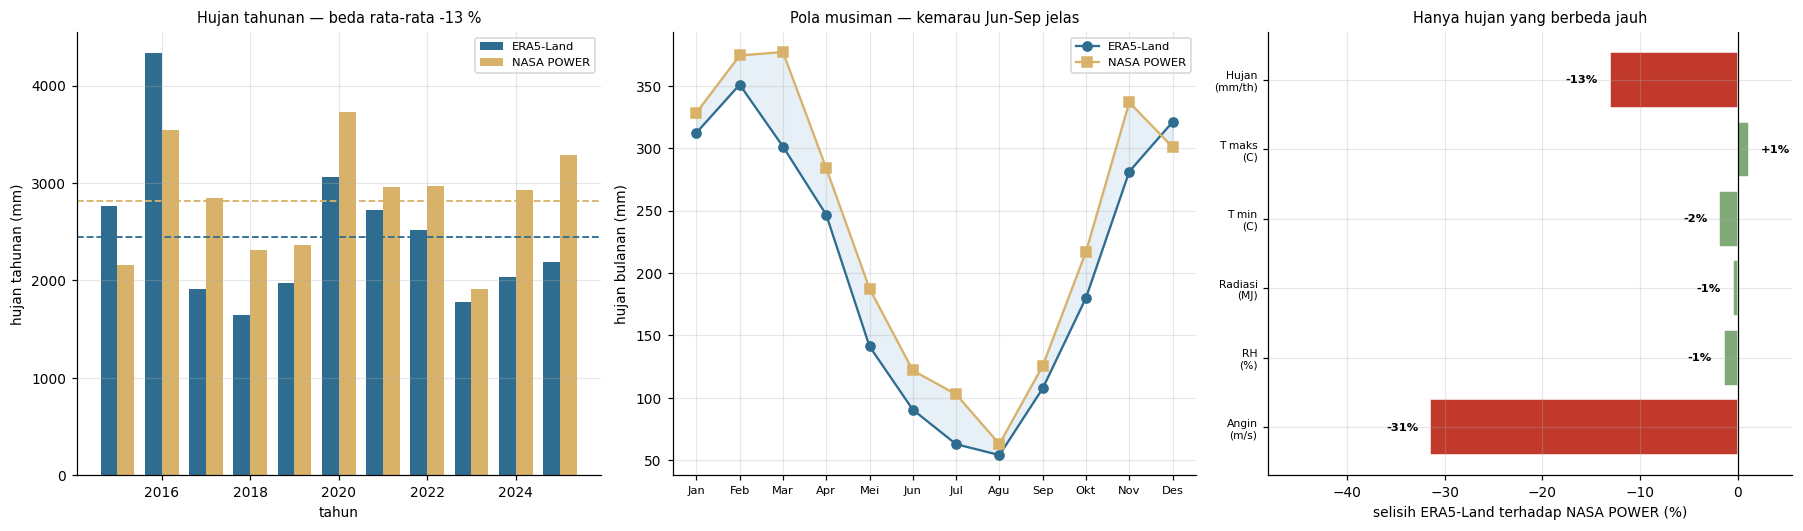

In [3]:
def ringkas_tahunan(df, nama):
    g = df.groupby("tahun").agg(hujan=("hujan","sum"), tmaks=("tmaks","mean"),
                                tmin=("tmin","mean"), rs=("rs","mean"),
                                rh=("rh","mean"), u2=("u2","mean"))
    g["sumber"] = nama
    return g

th_era, th_pw = ringkas_tahunan(era, "ERA5-Land"), ringkas_tahunan(pw, "NASA POWER")

baris = [("Hujan tahunan (mm)", th_era["hujan"].mean(), th_pw["hujan"].mean()),
         ("Suhu maks (C)",      th_era["tmaks"].mean(), th_pw["tmaks"].mean()),
         ("Suhu min (C)",       th_era["tmin"].mean(),  th_pw["tmin"].mean()),
         ("Radiasi (MJ/m2/hr)", th_era["rs"].mean(),    th_pw["rs"].mean()),
         ("Kelembapan (%)",     th_era["rh"].mean(),    th_pw["rh"].mean()),
         ("Angin 2 m (m/s)",    th_era["u2"].mean(),    th_pw["u2"].mean())]

print("=" * 76)
print(f"        PERBANDINGAN DUA SUMBER (rata-rata {TAHUN_AKHIR-TAHUN_AWAL+1} tahun)")
print("=" * 76)
print(f"  {'variabel':<26}{'ERA5-Land':>13}{'NASA POWER':>13}{'selisih':>13}")
print("-" * 76)
for n, a, b in baris:
    print(f"  {n:<26}{a:>13,.1f}{b:>13,.1f}{100*(a-b)/b:>12,.1f} %")
print("-" * 76)
beda = [abs(100*(a-b)/b) for _, a, b in baris]
paling = baris[int(np.argmax(beda))][0]
print(f"  Variabel yang paling berbeda : {paling} ({max(beda):.0f} %)")
print(f"  Variabel yang paling sepakat : {baris[int(np.argmin(beda))][0]} ({min(beda):.1f} %)")
bd_angin = abs(100*(th_era["u2"].mean()-th_pw["u2"].mean())/th_pw["u2"].mean())
bd_hujan = abs(100*(th_era["hujan"].mean()-th_pw["hujan"].mean())/th_pw["hujan"].mean())
print("-" * 76)
print("  Yang perlu ditimbang bukan besarnya selisih, tapi PENGARUHNYA ke hasil:")
print(f"  - Angin berbeda paling besar ({bd_angin:.0f} %), tetapi di udara lembap seperti ini")
print("    suku aerodinamis ETo kecil. Buktinya ada di bagian 2: ETo Penman-Monteith yang")
print("    dihitung atas KEDUA sumber hanya berbeda kurang dari 1 %. Jadi selisih angin")
print("    ini praktis tidak sampai ke angka kebutuhan air.")
print(f"  - Hujan berbeda {bd_hujan:.0f} %, dan INI yang menentukan kebutuhan irigasi. Hujan")
print("    tropis turun setempat dan sesaat, sedangkan kedua sumber punya sel grid puluhan")
print("    kilometer. Karena itu hujan tidak dipakai apa adanya: bagian 6 menjalankan")
print("    SETIAP musim satu per satu, lalu angka rancangan diambil dari sebarannya.")
print("  - Suhu, radiasi, dan kelembapan sepakat dalam 2 % -> ETo boleh dipercaya.")
print("=" * 76)

fig, axes = plt.subplots(1, 3, figsize=(16.5, 4.9))
ax = axes[0]
w = 0.38; xs = np.arange(TAHUN_AWAL, TAHUN_AKHIR+1)
ax.bar(xs-w/2, th_era["hujan"], w, label="ERA5-Land", color="#2f6d90")
ax.bar(xs+w/2, th_pw["hujan"],  w, label="NASA POWER", color="#d9b26a")
ax.axhline(th_era["hujan"].mean(), color="#2f6d90", ls="--", lw=1.2)
ax.axhline(th_pw["hujan"].mean(),  color="#d9b26a", ls="--", lw=1.2)
ax.set_ylabel("hujan tahunan (mm)"); ax.set_xlabel("tahun")
ax.set_title(f"Hujan tahunan — beda rata-rata "
             f"{100*(th_era['hujan'].mean()-th_pw['hujan'].mean())/th_pw['hujan'].mean():.0f} %",
             fontsize=9.5)
ax.legend(fontsize=7.5); ax.set_aspect("auto")

ax = axes[1]
nth = TAHUN_AKHIR - TAHUN_AWAL + 1
bl_e = era.groupby("bulan")["hujan"].sum()/nth
bl_p = pw.groupby("bulan")["hujan"].sum()/nth
ax.plot(range(1,13), bl_e, "o-", color="#2f6d90", label="ERA5-Land")
ax.plot(range(1,13), bl_p, "s-", color="#d9b26a", label="NASA POWER")
ax.fill_between(range(1,13), bl_p, bl_e, alpha=0.15, color="#5b9ec4")
ax.set_xticks(range(1,13)); ax.set_xticklabels(NB, fontsize=7.5)
ax.set_ylabel("hujan bulanan (mm)")
ax.set_title("Pola musiman — kemarau Jun-Sep jelas", fontsize=9.5)
ax.legend(fontsize=7.5); ax.set_aspect("auto")

ax = axes[2]
kat = ["Hujan\n(mm/th)","T maks\n(C)","T min\n(C)","Radiasi\n(MJ)","RH\n(%)","Angin\n(m/s)"]
bd = [100*(a-b)/b for _, a, b in baris]
ax.barh(range(6), bd, color=["#c0392b" if abs(v) > 10 else "#7faa78" for v in bd],
        edgecolor="white")
ax.axvline(0, color="black", lw=0.8)
ax.set_yticks(range(6)); ax.set_yticklabels(kat, fontsize=7)
ax.invert_yaxis(); ax.set_xlabel("selisih ERA5-Land terhadap NASA POWER (%)")
ax.set_title("Hanya hujan yang berbeda jauh", fontsize=9.5)
for i, v in enumerate(bd):
    ax.text(v + (1.2 if v >= 0 else -1.2), i, f"{v:+.0f}%", va="center",
            ha="left" if v >= 0 else "right", fontsize=7.5, weight="bold")
ax.set_aspect("auto"); ax.set_xlim(min(bd)*1.4-4, max(bd)*1.4+4)

plt.tight_layout()
simpan_gambar(fig, "01_dua_sumber_cuaca"); plt.show()

---
## 2. Evapotranspirasi acuan (ETo)

**FAO-56 Penman-Monteith** — semua variabelnya tersedia (suhu, kelembapan, angin,
radiasi):

$$ET_o=\frac{0{,}408\,\Delta\,(R_n-G)+\gamma\frac{900}{T+273}u_2(e_s-e_a)}{\Delta+\gamma(1+0{,}34\,u_2)}$$

Dihitung dari nol di sini supaya bisa diperiksa, **bukan** diambil jadi dari API.
Dua pembanding menguji dua hal yang **berbeda**:

1. **ETo bawaan Open-Meteo** — rumus yang sama pada data yang sama. Kalau cocok, berarti
   rumus di notebook ini ditulis benar. Ini **uji implementasi**.
2. **Hargreaves — Arif et al. (2015) pers. (1)**, rumus yang dipakai `note-swh.ipynb`:
   $$ET_o = 0{,}0135\,(T_{mean}+17{,}78)\,R_s\left(\frac{238{,}8}{595{,}5-0{,}55\,T_{mean}}\right)$$
   Ini **beda metode**, bukan uji benar-salah. Hargreaves tidak melihat kelembapan,
   sehingga di udara lembap ia cenderung melebih.

                  EVAPOTRANSPIRASI ACUAN (ETo)
  metode                                  mm/hari    mm/tahun
----------------------------------------------------------------------------
  FAO-56 Penman-Monteith (ERA5)              3.45       1,258   <- DIPAKAI
  ETo bawaan Open-Meteo                      3.54       1,293
  Hargreaves/Arif 2015 (ERA5)                4.09       1,493
  FAO-56 Penman-Monteith (POWER)             3.43       1,252
----------------------------------------------------------------------------
  Open-Meteo terhadap PM : +2.7 %   <- UJI IMPLEMENTASI
  Hargreaves terhadap PM : +18.6 %   <- BEDA METODE, bukan galat
----------------------------------------------------------------------------
  ETo TERVALIDASI: cocok dengan hitungan FAO-56 independen dalam 2.7 %
  -> rumus di notebook ini ditulis benar.

  Hargreaves +19 % memang diharapkan: rumus itu hanya memakai suhu dan
  radiasi, tidak melihat kelembapan, padahal RH di sini 87 %.
  Udara yang hampir jenuh menek

[gambar] 02_eto.png                             225 KB


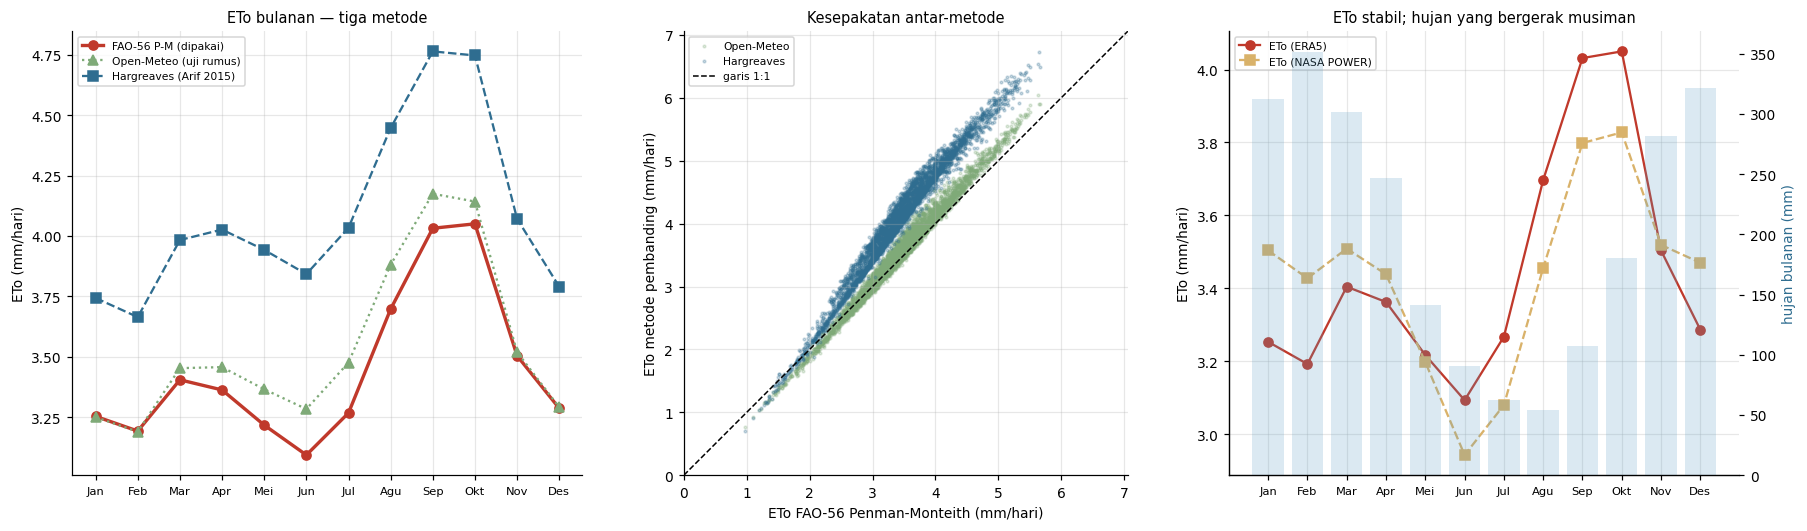

In [4]:
def radiasi_ekstra(doy, lat_deg):
    """Ra - radiasi ekstraterestrial (MJ m-2 hari-1). FAO-56 pers. (21)."""
    phi_ = math.radians(lat_deg)
    dr  = 1 + 0.033*np.cos(2*np.pi*doy/365)
    dec = 0.409*np.sin(2*np.pi*doy/365 - 1.39)
    ws  = np.arccos(np.clip(-np.tan(phi_)*np.tan(dec), -1, 1))
    return (24*60/np.pi)*0.0820*dr*(ws*np.sin(phi_)*np.sin(dec) +
                                    np.cos(phi_)*np.cos(dec)*np.sin(ws))

def eto_penman_monteith(tmaks, tmin, rh, u2, rs, doy, lat_deg, z):
    """ETo harian (mm/hari) menurut FAO-56 pers. (6)."""
    tmean = (tmaks + tmin)/2
    P     = 101.3*((293 - 0.0065*z)/293)**5.26
    gamma = 0.000665*P
    delta = (4098*(0.6108*np.exp(17.27*tmean/(tmean+237.3)))/(tmean+237.3)**2)
    e_maks = 0.6108*np.exp(17.27*tmaks/(tmaks+237.3))
    e_min  = 0.6108*np.exp(17.27*tmin /(tmin +237.3))
    es = (e_maks + e_min)/2
    ea = es*rh/100
    Ra  = radiasi_ekstra(doy, lat_deg)
    Rso = (0.75 + 2e-5*z)*Ra
    Rns = (1 - ALBEDO)*rs
    Rnl = (4.903e-9*(((tmaks+273.16)**4 + (tmin+273.16)**4)/2) *
           (0.34 - 0.14*np.sqrt(np.maximum(ea, 0))) *
           (1.35*np.clip(rs/Rso, 0, 1) - 0.35))
    Rn = Rns - Rnl                                  # G diabaikan untuk langkah harian
    return np.maximum((0.408*delta*Rn + gamma*(900/(tmean+273))*u2*(es-ea)) /
                      (delta + gamma*(1 + 0.34*u2)), 0)

def eto_hargreaves_arif(tmean, rs):
    """Arif et al. (2015) pers. (1) - Rs dalam MJ/m2/hari."""
    return 0.0135*(tmean + 17.78)*rs*(238.8/(595.5 - 0.55*tmean))

for df in (era, pw):
    df["eto_pm"] = eto_penman_monteith(df["tmaks"], df["tmin"], df["rh"], df["u2"],
                                       df["rs"], df["doy"], LAT, ELEVASI)
    df["eto_hg"] = eto_hargreaves_arif(df["tmean"], df["rs"])

ETO_RATA = float(era["eto_pm"].mean())
sel_om = 100*(era["eto_om"].mean()-ETO_RATA)/ETO_RATA
sel_hg = 100*(era["eto_hg"].mean()-ETO_RATA)/ETO_RATA

print("=" * 76)
print("                  EVAPOTRANSPIRASI ACUAN (ETo)")
print("=" * 76)
print(f"  {'metode':<36}{'mm/hari':>11}{'mm/tahun':>12}")
print("-" * 76)
print(f"  {'FAO-56 Penman-Monteith (ERA5)':<36}{ETO_RATA:>11.2f}{ETO_RATA*365:>12,.0f}   <- DIPAKAI")
print(f"  {'ETo bawaan Open-Meteo':<36}{era['eto_om'].mean():>11.2f}"
      f"{era['eto_om'].mean()*365:>12,.0f}")
print(f"  {'Hargreaves/Arif 2015 (ERA5)':<36}{era['eto_hg'].mean():>11.2f}"
      f"{era['eto_hg'].mean()*365:>12,.0f}")
print(f"  {'FAO-56 Penman-Monteith (POWER)':<36}{pw['eto_pm'].mean():>11.2f}"
      f"{pw['eto_pm'].mean()*365:>12,.0f}")
print("-" * 76)
print(f"  Open-Meteo terhadap PM : {sel_om:+.1f} %   <- UJI IMPLEMENTASI")
print(f"  Hargreaves terhadap PM : {sel_hg:+.1f} %   <- BEDA METODE, bukan galat")
print("-" * 76)
if abs(sel_om) < 5:
    print(f"  ETo TERVALIDASI: cocok dengan hitungan FAO-56 independen dalam "
          f"{abs(sel_om):.1f} %")
    print("  -> rumus di notebook ini ditulis benar.")
else:
    print(f"  PERIKSA: selisih {abs(sel_om):.1f} % terlalu besar untuk rumus yang sama.")
print(f"\n  Hargreaves {sel_hg:+.0f} % memang diharapkan: rumus itu hanya memakai suhu dan")
print(f"  radiasi, tidak melihat kelembapan, padahal RH di sini {era['rh'].mean():.0f} %.")
print("  Udara yang hampir jenuh menekan penguapan, dan Hargreaves tak melihatnya.")
print(f"  -> Penman-Monteith dipakai; Hargreaves dicatat sebagai BATAS ATAS.")
print("-" * 76)
print(f"  CATATAN untuk pembanding: note-swh.ipynb (SWH-011) memakai Hargreaves atas")
print(f"  cuaca buatan dan mendapat ETo ~4,7 mm/hari. Angka di sini {ETO_RATA:.2f} mm/hari")
print(f"  dari data nyata - jadi kedua notebook TIDAK boleh dibandingkan langsung.")
print("=" * 76)
print(f"  Pembanding lapangan: Arif et al. (2015) mengukur 3,5-6,0 mm/hari di sawah")
print(f"  Jawa Tengah (kemarau). Di sini {era['eto_pm'].min():.1f}-{era['eto_pm'].max():.1f} mm/hari.")
print("=" * 76)

fig, axes = plt.subplots(1, 3, figsize=(16.5, 4.9))
ax = axes[0]
bl = era.groupby("bulan")[["eto_pm","eto_hg","eto_om"]].mean()
ax.plot(range(1,13), bl["eto_pm"], "o-", lw=2.2, color="#c0392b", label="FAO-56 P-M (dipakai)")
ax.plot(range(1,13), bl["eto_om"], "^:", color="#7faa78", label="Open-Meteo (uji rumus)")
ax.plot(range(1,13), bl["eto_hg"], "s--", color="#2f6d90", label="Hargreaves (Arif 2015)")
ax.set_xticks(range(1,13)); ax.set_xticklabels(NB, fontsize=7.5)
ax.set_ylabel("ETo (mm/hari)"); ax.set_title("ETo bulanan — tiga metode", fontsize=9.5)
ax.legend(fontsize=7); ax.set_aspect("auto")

ax = axes[1]
ax.scatter(era["eto_pm"], era["eto_om"], s=3, alpha=0.25, color="#7faa78", label="Open-Meteo")
ax.scatter(era["eto_pm"], era["eto_hg"], s=3, alpha=0.25, color="#2f6d90", label="Hargreaves")
lim = [0, max(era["eto_pm"].max(), era["eto_hg"].max())*1.05]
ax.plot(lim, lim, "k--", lw=1, label="garis 1:1")
ax.set_xlabel("ETo FAO-56 Penman-Monteith (mm/hari)")
ax.set_ylabel("ETo metode pembanding (mm/hari)")
ax.set_title("Kesepakatan antar-metode", fontsize=9.5)
ax.legend(fontsize=7); ax.set_aspect("equal"); ax.set_xlim(lim); ax.set_ylim(lim)

ax = axes[2]
ax.plot(range(1,13), era.groupby("bulan")["eto_pm"].mean(), "o-", color="#c0392b",
        label="ETo (ERA5)")
ax.plot(range(1,13), pw.groupby("bulan")["eto_pm"].mean(), "s--", color="#d9b26a",
        label="ETo (NASA POWER)")
ax2 = ax.twinx()
ax2.bar(range(1,13), bl_e, alpha=0.22, color="#5b9ec4")
ax2.set_ylabel("hujan bulanan (mm)", color="#2f6d90"); ax2.grid(False)
ax.set_xticks(range(1,13)); ax.set_xticklabels(NB, fontsize=7.5)
ax.set_ylabel("ETo (mm/hari)")
ax.set_title("ETo stabil; hujan yang bergerak musiman", fontsize=9.5)
ax.legend(fontsize=7, loc="upper left"); ax.set_aspect("auto")

plt.tight_layout()
simpan_gambar(fig, "02_eto"); plt.show()

---
## 3. Hujan andalan (R80)

Untuk perencanaan, **hujan rata-rata tidak boleh dipakai** — separuh tahun akan lebih
kering dan jaringan gagal separuh waktu. KP-01 memakai **hujan andalan R80**: besaran
yang **terlampaui pada 8 dari 10 tahun**, dihitung per periode setengah-bulanan
(24 periode/tahun) supaya jeda kering di tengah bulan tidak tertutup rata-rata.

R80 di sini dipakai sebagai **gambaran musim kering rancangan dan penanda periode
kritis** — bukan sebagai masukan neraca harian. Neraca di bagian 6 sengaja memakai
**hujan harian sungguhan setiap tahun**, satu per satu, karena limpasan lewat lubang
buang hanya muncul kalau hujan datang bergerombol seperti aslinya; hujan yang sudah
dirata-ratakan per setengah bulan akan menghapus limpasan itu dan membuat water loss
tampak jauh lebih kecil daripada kenyataannya.

Angka rancangannya kemudian diambil dari **sebaran hasil** seluruh musim (persentil 80),
bukan dari satu tahun yang dipilih di muka.

        HUJAN ANDALAN R80 DAN HUJAN EFEKTIF (per setengah bulan)
  periode       rata2      R50      R80       Re
                 (mm)     (mm)     (mm)  (mm/hr)
--------------------------------------------------------------------------------
  Jan-I           156      176      102     4.75   ########
  Jan-II          156      145      121     5.28   ##########
  Feb-I           183      128       95     4.45   #######
  Feb-II          168      158      141     7.42   ###########
  Mar-I           162      140      130     6.06   ##########
  Mar-II          140      135       91     3.99   #######
  Apr-I           137      112       82     3.85   ######
  Apr-II          109      106       69     3.22   #####
  Mei-I            73       54       31     1.47   ##
  Mei-II           68       44       18     0.77   #
  Jun-I            52       44       31     1.46   ##
  Jun-II           39       35       24     1.10   #
  Jul-I            42       44       12     0.56   #
  Jul-II 

[gambar] 03_hujan_andalan.png                   134 KB


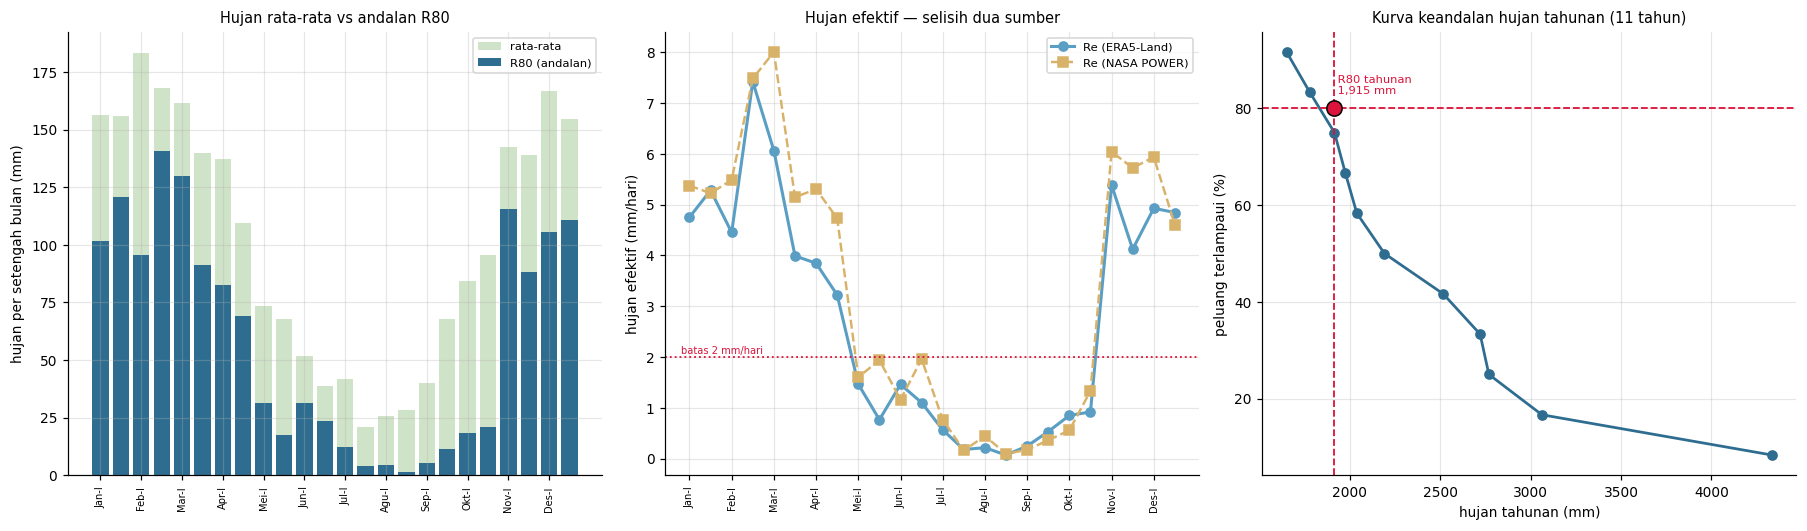

In [5]:
HARI_PERIODE = era.groupby(["tahun","periode"]).size().groupby("periode").mean()

def hujan_andalan(df, keandalan=80):
    """R80 per periode: hujan yang terlampaui pada `keandalan` % tahun."""
    tot = df.groupby(["tahun","periode"])["hujan"].sum().reset_index()
    return tot.groupby("periode")["hujan"].quantile(1 - keandalan/100)

R80  = hujan_andalan(era)
R50  = hujan_andalan(era, 50)
RRAT = era.groupby(["tahun","periode"])["hujan"].sum().groupby("periode").mean()
R80_PW = hujan_andalan(pw)
RE   = 0.7 * R80 / HARI_PERIODE          # hujan efektif KP-01 (mm/hari)

def label_periode(p):
    return f"{NB[(p-1)//2]}-{'I' if p % 2 else 'II'}"
LBL = [label_periode(p) for p in range(1, 25)]

print("=" * 80)
print("        HUJAN ANDALAN R80 DAN HUJAN EFEKTIF (per setengah bulan)")
print("=" * 80)
print(f"  {'periode':<10}{'rata2':>9}{'R50':>9}{'R80':>9}{'Re':>9}")
print(f"  {'':<10}{'(mm)':>9}{'(mm)':>9}{'(mm)':>9}{'(mm/hr)':>9}")
print("-" * 80)
for p in range(1, 25):
    print(f"  {LBL[p-1]:<10}{RRAT[p]:>9.0f}{R50[p]:>9.0f}{R80[p]:>9.0f}{RE[p]:>9.2f}"
          f"   {'#'*int(R80[p]/12)}")
print("-" * 80)
print(f"  Hujan tahunan rata-rata : {RRAT.sum():>7,.0f} mm")
r80_tahunan = float(np.quantile(era.groupby("tahun")["hujan"].sum().values, 0.2))
print(f"  Jumlah R80 per periode  : {R80.sum():>7,.0f} mm  <- BUKAN hujan tahunan andalan")
print(f"  Hujan tahunan andalan   : {r80_tahunan:>7,.0f} mm  (persentil 20 hujan tahunan)")
print(f"     Dua angka itu beda arti dan tidak boleh ditukar: menjumlahkan R80 tiap periode")
print(f"     berarti mengandaikan SEMUA periode kering serentak pada tahun yang sama -")
print(f"     keadaan yang tak pernah terjadi, sehingga jumlahnya "
      f"{100*(1-R80.sum()/r80_tahunan):.0f} % lebih rendah. R80 per")
print(f"     periode tetap benar sebagai masukan rancangan per periode (memang cara KP-01),")
print(f"     tapi jangan dikutip sebagai hujan setahun.")
print(f"  Hujan efektif tahunan   : {(RE*HARI_PERIODE).sum():>7,.0f} mm")
kering = [LBL[p-1] for p in range(1,25) if RE[p] < 2.0]
print(f"  Periode dengan Re < 2 mm/hari ({len(kering)} dari 24): "
      f"{', '.join(kering) if kering else 'tidak ada'}")
print("=" * 80)

fig, axes = plt.subplots(1, 3, figsize=(16.5, 4.9))
ax = axes[0]
xs = np.arange(1, 25)
ax.bar(xs, RRAT.values, color="#cfe3c8", label="rata-rata")
ax.bar(xs, R80.values, color="#2f6d90", label="R80 (andalan)")
ax.set_xticks(xs[::2]); ax.set_xticklabels(LBL[::2], rotation=90, fontsize=6.5)
ax.set_ylabel("hujan per setengah bulan (mm)")
ax.set_title("Hujan rata-rata vs andalan R80", fontsize=9.5)
ax.legend(fontsize=7.5); ax.set_aspect("auto")

ax = axes[1]
ax.plot(xs, RE.values, "o-", color="#5b9ec4", lw=2, label="Re (ERA5-Land)")
ax.plot(xs, (0.7*R80_PW/HARI_PERIODE).values, "s--", color="#d9b26a", lw=1.6,
        label="Re (NASA POWER)")
ax.axhline(2.0, color="crimson", ls=":", lw=1.2)
ax.text(0.6, 2.06, "batas 2 mm/hari", fontsize=6.5, color="crimson")
ax.set_xticks(xs[::2]); ax.set_xticklabels(LBL[::2], rotation=90, fontsize=6.5)
ax.set_ylabel("hujan efektif (mm/hari)")
ax.set_title("Hujan efektif — selisih dua sumber", fontsize=9.5)
ax.legend(fontsize=7.5); ax.set_aspect("auto")

ax = axes[2]
tot_th = era.groupby("tahun")["hujan"].sum().sort_values()
n = len(tot_th); prob = np.arange(1, n+1)/(n+1)*100
ax.plot(tot_th.values, 100-prob, "o-", color="#2f6d90", lw=1.8)
r80_th = float(np.quantile(tot_th.values, 0.2))
ax.axhline(80, color="crimson", ls="--", lw=1.2)
ax.axvline(r80_th, color="crimson", ls="--", lw=1.2)
ax.plot([r80_th], [80], "o", ms=10, mfc="crimson", mec="black", zorder=5)
ax.text(r80_th, 83, f" R80 tahunan\n {r80_th:,.0f} mm", fontsize=7.5, color="crimson")
ax.set_xlabel("hujan tahunan (mm)"); ax.set_ylabel("peluang terlampaui (%)")
ax.set_title(f"Kurva keandalan hujan tahunan ({n} tahun)", fontsize=9.5)
ax.set_aspect("auto")

plt.tight_layout()
simpan_gambar(fig, "03_hujan_andalan"); plt.show()

---
## 4. Koefisien tanaman, rezim air, dan aturan genangan

**Kc** diambil dari **Arif et al. (2015)**, hasil ukur langsung di sawah Indonesia —
bukan tabel FAO-56. Selisih keduanya dihitung di sel berikutnya, jadi tidak ditebak
di sini:

| Tahap | hari | Kc genangan (FL) | Kc SRI |
|---|---|---|---|
| Awal | 20 | 1,01 | 1,00 |
| Pertumbuhan | 30 | 1,02 | 0,96 |
| Reproduktif | 40 | **1,09** | 1,02 |
| Pemasakan | 20 | 1,05 | 1,04 |

Dua rezim dihitung sekaligus, karena bedanya inti penelitiannya: pada percobaan Arif,
SRI memakai air lebih sedikit **tetapi hasil gabahnya lebih tinggi** (8,05 vs 7,63 ton/ha).

> **SRI tidak cukup diwakili Kc saja.** Selisih Kc kedua rezim hanya ~4 %, padahal Arif
> melaporkan penghematan air **26 %**. Penghematan SRI datang dari petak yang **tidak
> digenangi terus**, bukan dari tanaman yang menguapkan lebih sedikit. Karena itu rezim
> SRI di sini juga memakai **perkolasi 0,60×**, **tanpa penggantian lapisan air**, dan
> **aturan genangan yang berbeda** (petak boleh kering sampai TMA negatif).

**Aturan genangan** mengikuti `note-swh.ipynb` — tiap tahap punya tinggi muka air (TMA)
target, pemicu pengairan, dan tinggi lubang buang. Inilah yang membuat limpasan bisa
dihitung: air di atas lubang buang langsung keluar dari petak.

In [6]:
FASE = [("awal", 20), ("pertumbuhan", 30), ("reproduktif", 40), ("pemasakan", 20)]
N_TUMBUH = sum(d for _, d in FASE)

KC = {"FL":  {"awal":1.01, "pertumbuhan":1.02, "reproduktif":1.09, "pemasakan":1.05},
      "SRI": {"awal":1.00, "pertumbuhan":0.96, "reproduktif":1.02, "pemasakan":1.04}}
KC_FAO = {"awal":1.05, "pertumbuhan":1.10, "reproduktif":1.20, "pemasakan":0.90}

# (TMA target, pemicu pengairan, tinggi lubang buang) dalam mm - sama dengan note-swh.ipynb
ATURAN_TMA = {
    "FL":  {"awal": (20, 10, 50), "pertumbuhan": (20, 10, 50),
            "reproduktif": (10, 5, 40), "pemasakan": (10, 0, 40)},
    "SRI": {"awal": (10, 0, 40), "pertumbuhan": (10, -20, 40),
            "reproduktif": (5, -25, 30), "pemasakan": (0, -30, 30)}}

REZIM = {"FL":  {"nama": "FL (genangan)",   "perk_faktor": 1.00, "wlr": WLR_MM},
         "SRI": {"nama": "SRI (intermiten)", "perk_faktor": 0.60, "wlr": 0.0}}

fase_harian = np.concatenate([[nm]*d for nm, d in FASE])

print("=" * 78)
print("        KOEFISIEN TANAMAN, REZIM AIR, DAN ATURAN GENANGAN")
print("=" * 78)
print(f"  Umur tanaman  : {N_TUMBUH} hari + {LAMA_SIAP_LAHAN} hari penyiapan lahan")
print(f"  {'tahap':<14}{'hari':>6}{'Kc FL':>8}{'Kc SRI':>8}{'Kc FAO':>8}"
      f"   {'TMA FL (target/pemicu/buang)':<30}{'TMA SRI':<24}")
print("-" * 78)
for nm, d in FASE:
    a, b = ATURAN_TMA["FL"][nm], ATURAN_TMA["SRI"][nm]
    print(f"  {nm:<14}{d:>6}{KC['FL'][nm]:>8.2f}{KC['SRI'][nm]:>8.2f}{KC_FAO[nm]:>8.2f}"
          f"   {f'{a[0]}/{a[1]}/{a[2]} mm':<30}{f'{b[0]}/{b[1]}/{b[2]} mm':<24}")
print("-" * 78)
kc_fl  = np.mean([KC["FL"][f] for f in fase_harian])
kc_sri = np.mean([KC["SRI"][f] for f in fase_harian])
kc_fao = np.mean([KC_FAO[f] for f in fase_harian])
print(f"  Kc rata-rata tertimbang : FL {kc_fl:.3f} | SRI {kc_sri:.3f} | FAO-56 {kc_fao:.3f}")
print(f"  Memakai FAO-56 akan melebihkan ETc sekitar {100*(kc_fao-kc_fl)/kc_fl:.0f} %.")
print("-" * 78)
print(f"  Rezim SRI: perkolasi {REZIM['SRI']['perk_faktor']:.2f}x, WLR "
      f"{REZIM['SRI']['wlr']:.0f} mm, dan petak boleh kering sampai TMA "
      f"{min(v[1] for v in ATURAN_TMA['SRI'].values())} mm.")
print("=" * 78)

        KOEFISIEN TANAMAN, REZIM AIR, DAN ATURAN GENANGAN
  Umur tanaman  : 110 hari + 30 hari penyiapan lahan
  tahap           hari   Kc FL  Kc SRI  Kc FAO   TMA FL (target/pemicu/buang)  TMA SRI                 
------------------------------------------------------------------------------
  awal              20    1.01    1.00    1.05   20/10/50 mm                   10/0/40 mm              
  pertumbuhan       30    1.02    0.96    1.10   20/10/50 mm                   10/-20/40 mm            
  reproduktif       40    1.09    1.02    1.20   10/5/40 mm                    5/-25/30 mm             
  pemasakan         20    1.05    1.04    0.90   10/0/40 mm                    0/-30/30 mm             
------------------------------------------------------------------------------
  Kc rata-rata tertimbang : FL 1.049 | SRI 1.004 | FAO-56 1.091
  Memakai FAO-56 akan melebihkan ETc sekitar 4 %.
------------------------------------------------------------------------------
  Rezim SRI: perko

---
## 5. Penyiapan lahan, perkolasi, dan penggantian lapisan air

Tiga suku yang sering dilupakan padahal besar.

**Penyiapan lahan** adalah **puncak kebutuhan air** sepanjang musim — tanah harus
dijenuhkan dan digenangi sebelum tanam. KP-01 memakai Van de Goor & Zijlstra:

$$IR=\frac{M\,e^{k}}{e^{k}-1},\qquad M=E_o+P,\qquad k=\frac{M\,T}{S}$$

dengan $E_o = 1{,}1\,ET_o$, $T$ = lama penyiapan (30 hari), $S$ = air penjenuhan (250 mm).

**Perkolasi** adalah ketidakpastian terbesar setelah hujan. Tanpa uji tanah dipakai
rentang KP-01 1–4 mm/hari dengan **2,0 mm/hari** sebagai acuan, dan pengaruhnya diuji
tersendiri di bagian 9. Tidak dipakai medan acak seperti `note-swh.ipynb`: pada berkas
ini tidak ada satu pun pengukuran tanah, jadi menyebar nilai secara acak hanya akan
membuat peta yang tampak berilmu tanpa isi.

**Penggantian lapisan air (WLR)** — 50 mm, dua kali semusim (KP-01), hanya untuk rezim
genangan.

In [7]:
def kebutuhan_siap_lahan(eto_mm, perkolasi, T=None, S=None):
    """IR penyiapan lahan (mm/hari) - Van de Goor & Zijlstra, KP-01."""
    T = LAMA_SIAP_LAHAN if T is None else T
    S = AIR_JENUH_S if S is None else S
    M = 1.1*eto_mm + perkolasi
    k = M*T/S
    return M*math.exp(k)/(math.exp(k) - 1.0)

print("=" * 76)
print("            PENYIAPAN LAHAN (Van de Goor & Zijlstra)")
print("=" * 76)
print(f"  ETo acuan {ETO_RATA:.2f} mm/hari | S = {AIR_JENUH_S:.0f} mm | "
      f"T = {LAMA_SIAP_LAHAN} hari")
print("-" * 76)
print(f"  {'perkolasi':<14}{'M = Eo+P':>12}{'k':>9}{'IR':>11}{'total':>12}{'volume':>14}")
print(f"  {'(mm/hari)':<14}{'(mm/hari)':>12}{'':>9}{'(mm/hari)':>11}{'(mm)':>12}{'(m3)':>14}")
for p in PERKOLASI_UJI:
    ir = kebutuhan_siap_lahan(ETO_RATA, p); M = 1.1*ETO_RATA + p
    print(f"  {p:<14.1f}{M:>12.2f}{M*LAMA_SIAP_LAHAN/AIR_JENUH_S:>9.2f}{ir:>11.2f}"
          f"{ir*LAMA_SIAP_LAHAN:>12.0f}{ir*LAMA_SIAP_LAHAN*LUAS_M2/1000:>14,.0f}")
IR_ACUAN = kebutuhan_siap_lahan(ETO_RATA, PERKOLASI_MM)
print("-" * 76)
print(f"  Pada perkolasi acuan {PERKOLASI_MM:.1f} mm/hari: IR = {IR_ACUAN:.2f} mm/hari "
      f"selama {LAMA_SIAP_LAHAN} hari")
print(f"  = {IR_ACUAN*LAMA_SIAP_LAHAN:,.0f} mm = "
      f"{IR_ACUAN*LAMA_SIAP_LAHAN*LUAS_M2/1000:,.0f} m3 untuk {LUAS_HA:.2f} ha")
print(f"  Bandingkan ETc puncak ~{1.09*ETO_RATA:.2f} mm/hari -> penyiapan lahan "
      f"{IR_ACUAN/(1.09*ETO_RATA):.1f}x lebih haus.")
print("=" * 76)
print("  Kapasitas saluran ditentukan di sini, BUKAN di masa tumbuh.")
print("=" * 76)

            PENYIAPAN LAHAN (Van de Goor & Zijlstra)
  ETo acuan 3.45 mm/hari | S = 250 mm | T = 30 hari
----------------------------------------------------------------------------
  perkolasi         M = Eo+P        k         IR       total        volume
  (mm/hari)        (mm/hari)           (mm/hari)        (mm)          (m3)
  1.0                   4.79     0.58      10.96         329        25,283
  2.0                   5.79     0.70      11.56         347        26,678
  3.0                   6.79     0.82      12.19         366        28,116
  4.0                   7.79     0.94      12.83         385        29,598
----------------------------------------------------------------------------
  Pada perkolasi acuan 2.0 mm/hari: IR = 11.56 mm/hari selama 30 hari
  = 347 mm = 26,678 m3 untuk 7.69 ha
  Bandingkan ETc puncak ~3.76 mm/hari -> penyiapan lahan 3.1x lebih haus.
  Kapasitas saluran ditentukan di sini, BUKAN di masa tumbuh.


---
## 6. Neraca air harian

Tiap hari, untuk satu petak:

$$h_{besok} = h_{hari\ ini} + \underbrace{Hujan + Irigasi}_{masuk} - \underbrace{ET_c + Perkolasi + Limpasan}_{keluar}$$

| Komponen | Aturan |
|---|---|
| ETc | `Kc × ETo` harian dari cuaca nyata |
| Perkolasi | `P` saat tergenang, `0,60 P` saat tidak tergenang |
| Limpasan | kelebihan di atas tinggi lubang buang langsung keluar |
| Irigasi | kalau `TMA < pemicu` → isi sampai `target` |
| Penyiapan lahan | 30 hari pertama: `IR` Van de Goor, hujan menggantikan irigasi |

Neraca dijalankan untuk **11 musim × 2 rezim** memakai hujan dan suhu harian sungguhnya,
bukan satu tahun terpilih. Hasilnya jadi **sebaran**, sehingga bisa dibedakan:

- **musim tengahan (median)** — pemakaian air yang wajar diharapkan;
- **musim andalan (persentil 80)** — yang dipakai **merancang**, karena jaringan harus
  tetap cukup pada tahun kering.

Selama penyiapan lahan, air yang masuk tidak semuanya hilang: sebagian **tersimpan**
sebagai penjenuhan tanah. Itu dicatat sendiri supaya neraca tertutup dan tidak
tercampur ke water loss.

In [8]:
def neraca_musim(tanam, rezim, cuaca, perkolasi=None):
    """Neraca harian satu musim (penyiapan lahan + masa tumbuh) -> DataFrame."""
    perkolasi = PERKOLASI_MM if perkolasi is None else perkolasi
    perk_tumbuh = perkolasi * REZIM[rezim]["perk_faktor"]
    wlr_total   = REZIM[rezim]["wlr"]
    mulai = tanam - timedelta(days=LAMA_SIAP_LAHAN)
    n = LAMA_SIAP_LAHAN + N_TUMBUH

    # cuaca musim ini, diambil sekali (bukan disaring ulang tiap hari)
    m = cuaca.set_index("tanggal")
    idx = pd.date_range(mulai, periods=n, freq="D")
    if not idx.isin(m.index).all():
        return None                      # data cuaca musim ini tidak lengkap
    cm = m.loc[idx]
    eto_h = cm["eto_pm"].to_numpy(); hj_h = cm["hujan"].to_numpy()

    h = 0.0
    baris = []
    for i in range(n):
        eto, hj = float(eto_h[i]), float(hj_h[i])
        if i < LAMA_SIAP_LAHAN:                        # ---- penyiapan lahan ----
            ir   = kebutuhan_siap_lahan(eto, perkolasi)
            irig = max(ir - hj, 0.0)
            etc  = 1.1*eto                             # Eo: penguapan permukaan air
            perk = perkolasi
            simpan = max(ir - etc - perk, 0.0)         # penjenuhan tanah - TERSIMPAN
            limp = max(hj - ir, 0.0)                   # hujan berlebih tetap keluar
            tahap, wlr = "siap lahan", 0.0
            tma = 0.0
        else:                                          # ---- masa tumbuh ----
            k = i - LAMA_SIAP_LAHAN
            tahap = fase_harian[k]
            target, pemicu, hd = ATURAN_TMA[rezim][tahap]
            h += hj
            irig = 0.0
            if h < pemicu:
                irig = target - h; h = float(target)
            etc = KC[rezim][tahap]*eto
            perk = perk_tumbuh if h > 0 else perk_tumbuh*PERK_KERING_RASIO
            wlr = wlr_total/15.0 if (30 <= k < 45) or (60 <= k < 75) else 0.0
            irig += wlr                                # penggantian lapisan air
            h += wlr
            h -= (etc + perk)
            limp = 0.0
            if h > hd:
                limp = h - hd; h = float(hd)
            h = max(h, -150.0)
            simpan, tma = 0.0, h
        baris.append({"hari_ke": i - LAMA_SIAP_LAHAN, "tanggal": idx[i], "tahap": tahap,
                      "eto": eto, "hujan": hj, "irigasi": irig, "etc": etc,
                      "perkolasi": perk, "limpasan": limp, "wlr": wlr,
                      "penjenuhan": simpan, "tma": tma})
    return pd.DataFrame(baris)

def ringkas_musim(df):
    """Satu baris angka pokok dari neraca harian satu musim."""
    tumbuh = df[df["tahap"] != "siap lahan"]
    keluar = df["etc"].sum() + df["perkolasi"].sum() + df["limpasan"].sum()
    masuk  = df["hujan"].sum() + df["irigasi"].sum()
    return {
        "hujan_mm": df["hujan"].sum(), "irigasi_mm": df["irigasi"].sum(),
        "irigasi_pl_mm": df[df["tahap"] == "siap lahan"]["irigasi"].sum(),
        "etc_mm": df["etc"].sum(), "perkolasi_mm": df["perkolasi"].sum(),
        "limpasan_mm": df["limpasan"].sum(), "wlr_mm": df["wlr"].sum(),
        "penjenuhan_mm": df["penjenuhan"].sum(),
        "masuk_mm": masuk, "keluar_mm": keluar,
        "tma_rata": tumbuh["tma"].mean(), "tma_min": tumbuh["tma"].min(),
        "hari_diairi": int((df["irigasi"] > 0.001).sum()),
        "hari_kering": int((tumbuh["tma"] < 0).sum()),
        "hari_limpas": int((df["limpasan"] > 0.001).sum()),
    }

# ---------- pilih tanggal tanam: pindai 12 bulan ----------
TAHUN_MUSIM = list(range(TAHUN_AWAL, TAHUN_AKHIR))     # musim terakhir butuh tahun +1
pindai = []
for bulan in range(1, 13):
    for rz in REZIM:
        nilai = []
        for th in TAHUN_MUSIM:
            df = neraca_musim(date(th, bulan, 1), rz, era)
            if df is not None:
                nilai.append(ringkas_musim(df)["irigasi_mm"])
        if nilai:
            pindai.append({"bulan": bulan, "bulan_nama": NB[bulan-1], "rezim": rz,
                           "n_musim": len(nilai),
                           "irigasi_median": float(np.median(nilai)),
                           "irigasi_andalan": float(np.percentile(nilai, 80))})
PINDAI = pd.DataFrame(pindai)

terbaik = (PINDAI[PINDAI.rezim == "FL"].sort_values("irigasi_median").iloc[0])
BULAN_TANAM = int(terbaik["bulan"])

print("=" * 80)
n_musim_pindai = int(PINDAI["n_musim"].max())
print(f"     PEMINDAIAN TANGGAL TANAM — irigasi semusim (mm), {n_musim_pindai} musim")
print("=" * 80)
print(f"  {'tanam':<8}" + "".join(f"{REZIM[r]['nama']:>26}" for r in REZIM))
print(f"  {'':<8}" + "".join(f"{'median':>13}{'andalan':>13}" for _ in REZIM))
print("-" * 80)
for b in range(1, 13):
    sel = PINDAI[PINDAI.bulan == b]
    baris = f"  {NB[b-1]+'-1':<8}"
    for r in REZIM:
        s = sel[sel.rezim == r]
        baris += f"{s['irigasi_median'].iloc[0]:>13,.0f}{s['irigasi_andalan'].iloc[0]:>13,.0f}"
    print(baris + ("   <- dipakai" if b == BULAN_TANAM else ""))
print("-" * 80)
print(f"  Tanam paling hemat air (rezim FL) : awal {NB[BULAN_TANAM-1]}")
print(f"  Selisih terhadap tanam paling boros: "
      f"{PINDAI[PINDAI.rezim=='FL']['irigasi_median'].max() - terbaik['irigasi_median']:,.0f} mm "
      f"({100*(PINDAI[PINDAI.rezim=='FL']['irigasi_median'].max()/terbaik['irigasi_median']-1):.0f} % lebih boros)")
print("  -> memilih tanggal tanam adalah keputusan termurah yang paling berpengaruh")
print("     pada pemakaian air. Tidak ada bangunan yang perlu dibeli.")
print("=" * 80)

     PEMINDAIAN TANGGAL TANAM — irigasi semusim (mm), 10 musim
  tanam                FL (genangan)          SRI (intermiten)
                 median      andalan       median      andalan
--------------------------------------------------------------------------------
  Jan-1             230          284          123          184   <- dipakai
  Feb-1             284          306          144          169
  Mar-1             296          352          180          212
  Apr-1             355          466          232          317
  Mei-1             518          608          367          447
  Jun-1             717          845          553          692
  Jul-1             712          896          566          724
  Agu-1             712          878          554          736
  Sep-1             608          756          478          616
  Okt-1             487          632          344          503
  Nov-1             393          468          287          352
  Des-1             265 

In [9]:
# ---------- jalankan 11 musim x 2 rezim pada tanggal tanam terpilih ----------
TANAM_ACUAN = date(TAHUN_MUSIM[0], BULAN_TANAM, 1)
musim_harian, musim_ringkas = {}, []
for rz in REZIM:
    for th in TAHUN_MUSIM:
        df = neraca_musim(date(th, BULAN_TANAM, 1), rz, era)
        if df is None:
            continue
        musim_harian[(rz, th)] = df
        r = ringkas_musim(df); r.update({"rezim": rz, "tahun_tanam": th})
        # cek penutupan neraca: masuk - keluar - tersimpan - sisa genangan = 0
        sisa = (r["masuk_mm"] - r["keluar_mm"] - r["penjenuhan_mm"]
                - df["tma"].iloc[-1])
        r["galat_neraca_mm"] = sisa
        musim_ringkas.append(r)
MUSIM = pd.DataFrame(musim_ringkas)
N_MUSIM_JALAN = int(MUSIM["tahun_tanam"].nunique())

galat_maks = MUSIM["galat_neraca_mm"].abs().max()
print(f"Simulasi: {len(REZIM)} rezim x {N_MUSIM_JALAN} musim x "
      f"{LAMA_SIAP_LAHAN + N_TUMBUH} hari = {len(MUSIM)*(LAMA_SIAP_LAHAN+N_TUMBUH):,} langkah hari")
if N_MUSIM_JALAN < len(TAHUN_MUSIM):
    print(f"  ({len(TAHUN_MUSIM)-N_MUSIM_JALAN} musim dilewati: penyiapan lahannya mulai "
          f"sebelum {TAHUN_AWAL}, di luar rentang data)")
print(f"Galat penutupan neraca terbesar: {galat_maks:.9f} mm -> "
      f"{'NERACA TERTUTUP' if galat_maks < 1e-6 else 'PERIKSA'}")

# ---------- musim tengahan & musim andalan per rezim ----------
STAT = {}
for rz in REZIM:
    d = MUSIM[MUSIM.rezim == rz]
    # select_dtypes, bukan uji "dtype != object": di pandas 3 kolom teks bertipe string
    # (bukan object) sehingga uji itu meloloskannya dan np.median gagal.
    ang = d.select_dtypes(include="number")
    med   = {k: float(np.median(ang[k])) for k in ang.columns}
    and80 = {k: float(np.percentile(ang[k], 80)) for k in ang.columns}
    th_med = int(d.iloc[(d["irigasi_mm"] - med["irigasi_mm"]).abs().argsort().iloc[0]]["tahun_tanam"])
    STAT[rz] = {"median": med, "andalan": and80, "tahun_median": th_med}

print("\n" + "=" * 82)
print(f"   NERACA AIR SEMUSIM — tanam {NB[BULAN_TANAM-1]}, {N_PETAK} petak, {LUAS_HA:.2f} ha")
print("=" * 82)
for rz in REZIM:
    d = MUSIM[MUSIM.rezim == rz]
    m, a = STAT[rz]["median"], STAT[rz]["andalan"]
    print(f"\n  {REZIM[rz]['nama']}   (musim tengahan {STAT[rz]['tahun_median']})")
    print(f"    {'':<22}{'median':>12}{'andalan 80%':>14}{'terendah':>12}{'tertinggi':>12}")
    for k, lbl in (("hujan_mm","Hujan"), ("irigasi_mm","Irigasi (NFR petak)"),
                   ("etc_mm","ETc menguap"), ("perkolasi_mm","Perkolasi meresap"),
                   ("limpasan_mm","Limpasan keluar"), ("keluar_mm","Total keluar")):
        print(f"    {lbl:<22}{m[k]:>12,.0f}{a[k]:>14,.0f}{d[k].min():>12,.0f}"
              f"{d[k].max():>12,.0f}   mm")
    print(f"    {'Hari diairi':<22}{m['hari_diairi']:>12,.0f}{a['hari_diairi']:>14,.0f}"
          f"{d['hari_diairi'].min():>12,.0f}{d['hari_diairi'].max():>12,.0f}   hari")
    print(f"    {'TMA rata-rata':<22}{m['tma_rata']:>12,.1f}{'':>14}{d['tma_rata'].min():>12,.1f}"
          f"{d['tma_rata'].max():>12,.1f}   mm")
fl_m, sri_m = STAT["FL"]["median"], STAT["SRI"]["median"]
hemat = fl_m["irigasi_mm"] - sri_m["irigasi_mm"]
print()
print("-" * 82)
print(f"  SRI memakai {hemat:,.0f} mm lebih sedikit "
      f"({100*hemat/fl_m['irigasi_mm']:.0f} % dari irigasi FL)")
print(f"  Arif et al. (2015) mencatat penghematan 26 % - angka di sini tampak jauh lebih")
print(f"  besar, dan sebabnya harus disebut: {fl_m['wlr_mm']:.0f} mm dari {hemat:,.0f} mm itu semata")
print(f"  penggantian lapisan air (WLR) yang tidak dilakukan SRI. Persennya melonjak karena")
print(f"  PENYEBUTNYA kecil - irigasi FL hanya {fl_m['irigasi_mm']:,.0f} mm pada tanam musim hujan.")
print(f"  Yang layak dikutip adalah selisih mm-nya, bukan persennya.")
print("-" * 82)
print(f"  Pembanding Arif (Wonogiri, kemarau): FL 536 mm, SRI 518 mm irigasi per musim.")
print(f"  Di sini tanam {NB[BULAN_TANAM-1]} hanya {fl_m['irigasi_mm']:,.0f} mm - bukan karena tanamannya")
print(f"  beda, melainkan karena hujan {fl_m['hujan_mm']:,.0f} mm sudah menanggung hampir semuanya.")
p_kering = PINDAI[PINDAI.rezim == "FL"].sort_values("irigasi_median").iloc[-1]
print(f"  Tanam di musim kering ({p_kering['bulan_nama']}) memberi "
      f"{p_kering['irigasi_median']:,.0f} mm - dan angka itulah")
print(f"  yang sepadan dibandingkan dengan 536 mm milik Arif.")
print(f"  Yang bisa dibandingkan langsung tanpa syarat adalah ETc: {fl_m['etc_mm']:,.0f} mm.")
print("-" * 82)
d_fl = MUSIM[MUSIM.rezim == "FL"]
print(f"  Sebaran antar-musim irigasi FL: {d_fl['irigasi_mm'].min():,.0f} - "
      f"{d_fl['irigasi_mm'].max():,.0f} mm "
      f"(selisih {d_fl['irigasi_mm'].max()-d_fl['irigasi_mm'].min():,.0f} mm, "
      f"{100*(d_fl['irigasi_mm'].max()/d_fl['irigasi_mm'].min()-1):.0f} %)")
print("  -> keragaman antar-tahun jauh lebih besar daripada beda antar-petak, dan itu")
print("     sebabnya angka rancangan memakai musim andalan, bukan rata-rata.")
print("-" * 82)
print(f"  PERHATIKAN LIMPASAN: {fl_m['limpasan_mm']:,.0f} mm - lebih besar daripada ETc "
      f"({fl_m['etc_mm']:,.0f} mm)")
print(f"  dan {fl_m['limpasan_mm']/fl_m['irigasi_mm']:.1f}x irigasi. Itu BUKAN irigasi yang terbuang:")
print(f"  pada tanam musim hujan, hujan {fl_m['hujan_mm']:,.0f} mm jauh melebihi yang bisa")
print(f"  ditampung petak, jadi selisihnya keluar lewat lubang buang - dan tetap berguna bagi")
print(f"  petak di bawahnya. Water loss karena itu harus dibaca per jalan keluar (bagian 8),")
print(f"  bukan sebagai satu angka keborosan.")
print("=" * 82)
MUSIM.round(1)

Simulasi: 2 rezim x 9 musim x 140 hari = 2,520 langkah hari
  (1 musim dilewati: penyiapan lahannya mulai sebelum 2015, di luar rentang data)
Galat penutupan neraca terbesar: 0.000000000 mm -> NERACA TERTUTUP

   NERACA AIR SEMUSIM — tanam Jan, 41 petak, 7.69 ha

  FL (genangan)   (musim tengahan 2017)
                                median   andalan 80%    terendah   tertinggi
    Hujan                        1,380         1,646         986       2,166   mm
    Irigasi (NFR petak)            230           284         204         390   mm
    ETc menguap                    488           498         450         554   mm
    Perkolasi meresap              280           280         280         280   mm
    Limpasan keluar                668           903         399       1,433   mm
    Total keluar                 1,404         1,672       1,195       2,181   mm
    Hari diairi                     49            52          44          60   hari
    TMA rata-rata                 39.3     

,hujan_mm,irigasi_mm,irigasi_pl_mm,etc_mm,perkolasi_mm,limpasan_mm,wlr_mm,penjenuhan_mm,masuk_mm,keluar_mm,tma_rata,tma_min,hari_diairi,hari_kering,hari_limpas,rezim,tahun_tanam,galat_neraca_mm
0,2166.1,227.3,127.3,467.9,280.0,1432.7,100.0,177.6,2393.4,2180.6,42.8,27.6,47,0,93,FL,2016,0.0
1,1380.3,230.4,105.1,472.8,280.0,667.7,100.0,178.0,1610.7,1420.5,33.5,1.9,46,0,61,FL,2017,-0.0
2,986.0,390.2,223.2,488.1,280.0,427.2,100.0,176.4,1376.2,1195.2,32.4,-5.6,60,8,44,FL,2018,-0.0
3,1552.1,252.3,152.3,486.4,280.0,825.5,100.0,175.7,1804.4,1591.9,41.5,7.7,49,0,74,FL,2019,0.0
4,1786.4,214.5,114.5,493.6,280.0,1018.0,100.0,171.7,2000.9,1791.6,41.8,16.5,49,0,88,FL,2020,0.0
5,1395.0,204.1,88.8,450.0,280.0,674.0,100.0,180.8,1599.1,1404.0,39.3,13.0,44,0,70,FL,2021,-0.0
6,1256.6,240.3,111.1,504.3,280.0,496.6,100.0,176.0,1496.9,1280.9,39.7,4.1,50,0,65,FL,2022,-0.0
7,1259.1,206.7,95.3,489.4,280.0,490.3,100.0,177.6,1465.8,1259.6,36.1,3.5,49,0,56,FL,2023,-0.0
8,1076.1,330.8,230.8,554.3,280.0,399.4,100.0,164.6,1406.9,1233.7,33.7,2.4,54,0,43,FL,2024,-0.0
9,2166.1,127.3,127.3,452.3,192.0,1444.6,0.0,177.6,2293.4,2088.9,33.1,12.0,17,0,97,SRI,2016,0.0


[gambar] 04_neraca_harian.png                   376 KB


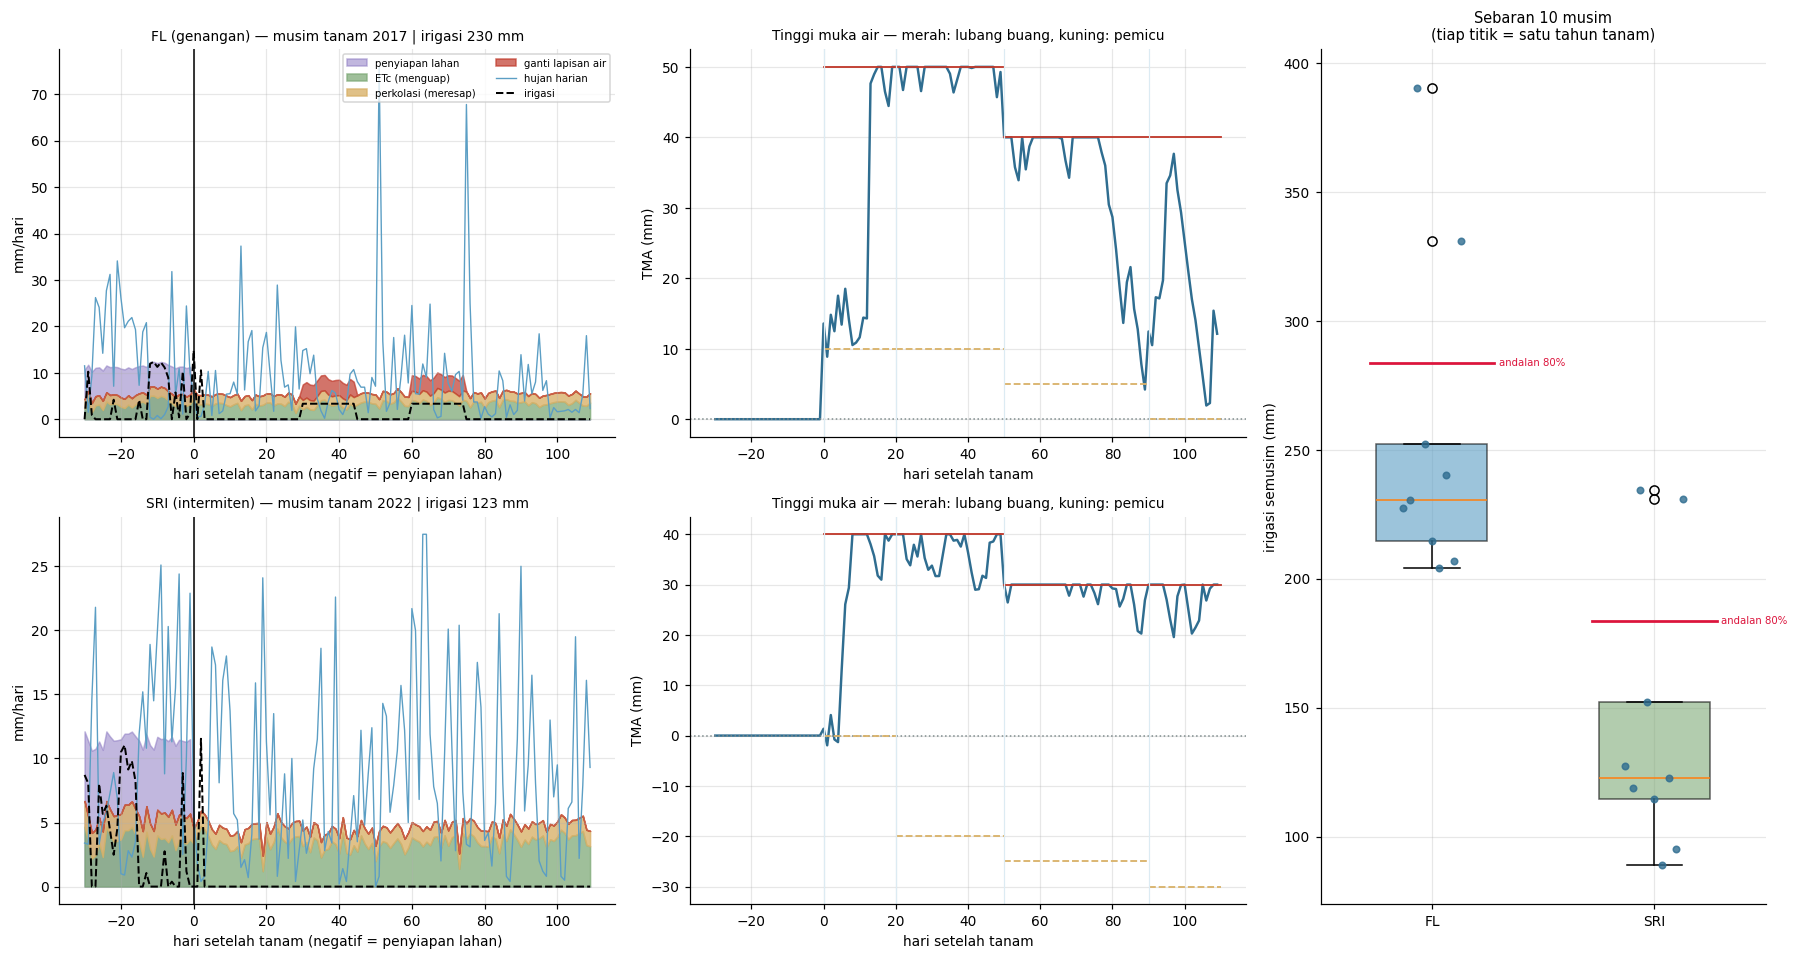

In [10]:
# ---------- gambar: susunan kebutuhan harian + sebaran antar-musim ----------
fig = plt.figure(figsize=(16.5, 8.8))
gs = fig.add_gridspec(2, 3, width_ratios=[1.25, 1.25, 1])

for r, rz in enumerate(REZIM):
    th = STAT[rz]["tahun_median"]
    df = musim_harian[(rz, th)]
    ax = fig.add_subplot(gs[r, 0])
    x = df["hari_ke"]
    etc = df["etc"].to_numpy(); perk = df["perkolasi"].to_numpy(); wlr = df["wlr"].to_numpy()
    siap = np.where(df["tahap"] == "siap lahan",
                    etc + perk + df["penjenuhan"].to_numpy(), 0)
    ax.fill_between(x, 0, siap, color="#8e7cc3", alpha=0.55, label="penyiapan lahan")
    ax.fill_between(x, 0, etc, color="#7faa78", alpha=0.75, label="ETc (menguap)")
    ax.fill_between(x, etc, etc+perk, color="#d9b26a", alpha=0.8, label="perkolasi (meresap)")
    ax.fill_between(x, etc+perk, etc+perk+wlr, color="#c0392b", alpha=0.7, label="ganti lapisan air")
    ax.plot(x, df["hujan"], color="#5b9ec4", lw=0.9, label="hujan harian")
    ax.plot(x, df["irigasi"], color="black", lw=1.3, ls="--", label="irigasi")
    ax.axvline(0, color="black", lw=1.0)
    ax.set_xlabel("hari setelah tanam (negatif = penyiapan lahan)")
    ax.set_ylabel("mm/hari")
    ax.set_title(f"{REZIM[rz]['nama']} — musim tanam {th} | irigasi "
                 f"{df['irigasi'].sum():,.0f} mm", fontsize=9)
    ax.set_aspect("auto")
    if r == 0:
        ax.legend(fontsize=6.6, ncol=2, loc="upper right")

    ax = fig.add_subplot(gs[r, 1])
    ax.plot(df["hari_ke"], df["tma"], color="#2f6d90", lw=1.6)
    ax.axhline(0, color="#7f8c8d", lw=1.0, ls=":")
    b = 0
    for nm, d_ in FASE:
        target, pemicu, hd = ATURAN_TMA[rz][nm]
        ax.plot([b, b+d_], [hd, hd], color="#c0392b", lw=1.2)
        ax.plot([b, b+d_], [pemicu, pemicu], color="#d9b26a", lw=1.2, ls="--")
        ax.axvline(b, color="#dcebf3", lw=0.8)
        b += d_
    ax.set_xlabel("hari setelah tanam"); ax.set_ylabel("TMA (mm)")
    ax.set_title(f"Tinggi muka air — merah: lubang buang, kuning: pemicu", fontsize=9)
    ax.set_aspect("auto")

ax = fig.add_subplot(gs[:, 2])
data_box = [MUSIM[MUSIM.rezim == rz]["irigasi_mm"].values for rz in REZIM]
bp = ax.boxplot(data_box, tick_labels=[REZIM[r]["nama"].split()[0] for r in REZIM],
                patch_artist=True, widths=0.5)
for patch, c in zip(bp["boxes"], ["#5b9ec4", "#7faa78"]):
    patch.set_facecolor(c); patch.set_alpha(0.6)
for rz, xpos in zip(REZIM, (1, 2)):
    d = MUSIM[MUSIM.rezim == rz]
    ax.scatter(np.full(len(d), xpos) + np.linspace(-0.13, 0.13, len(d)),
               d["irigasi_mm"], s=18, color="#2f6d90", zorder=5, alpha=0.8)
    ax.plot([xpos-0.28, xpos+0.28], [STAT[rz]["andalan"]["irigasi_mm"]]*2,
            color="crimson", lw=1.8)
    ax.text(xpos+0.30, STAT[rz]["andalan"]["irigasi_mm"], "andalan 80%",
            fontsize=6.6, color="crimson", va="center")
ax.set_ylabel("irigasi semusim (mm)")
ax.set_title(f"Sebaran {len(TAHUN_MUSIM)} musim\n(tiap titik = satu tahun tanam)", fontsize=9.5)
ax.set_aspect("auto")

plt.tight_layout()
simpan_gambar(fig, "04_neraca_harian"); plt.show()

---
## 7. Kebutuhan air per petak ← pertanyaan 1

Dua satuan yang **berbeda artinya**:

- **mm** = seberapa haus per satuan luas. Sama untuk semua petak di sini (lihat catatan
  di awal: sifat tanah belum diukur).
- **m³** = jumlah air sebenarnya. Berbanding lurus dengan luas petak — **ini yang dipakai
  merencanakan volume dan debit**.

Debit dihitung tiga tingkat, dan ketiganya sering tertukar:

| Istilah | Artinya | Untuk apa |
|---|---|---|
| **NFR** | kebutuhan bersih di petak (mm/hari) | dasar hitungan |
| **DR** | yang harus diambil di bendung (l/detik/ha) | perencanaan jaringan |
| **Debit pengisian** | debit sesaat saat mengisi petak | menentukan ukuran pintu |

$$DR = \frac{NFR}{8{,}64 \times e}$$

Angka 8,64 hanya konversi satuan: 1 mm/hari di 1 ha = 10.000 L / 86.400 detik
= 0,1157 l/detik, dan 1 ÷ 0,1157 = 8,64. Efisiensi $e$ = 0,65 (KP-01) berarti **35 % air
yang diambil hilang di jaringan** sebelum sampai petak.

In [11]:
N_HARI_MUSIM = LAMA_SIAP_LAHAN + N_TUMBUH

def ke_l_detik_ha(nfr_mm_hari, efisiensi=EFISIENSI_IRIGASI):
    return nfr_mm_hari / (8.64 * efisiensi)

def diameter_orifice(Q_m3s, tinggi_tekan_m=0.010, Cd=0.62):
    """Diameter lubang pintu (m) untuk debit Q - persamaan orifice dibalik."""
    if Q_m3s <= 0:
        return 0.0
    return math.sqrt(4.0*(Q_m3s/(Cd*math.sqrt(2*9.81*tinggi_tekan_m)))/math.pi)

ZONA_AKAR_MM, THETA_JENUH, THETA_AWAL = 300.0, 0.50, 0.30
PENJENUHAN_MM = (THETA_JENUH - THETA_AWAL)*ZONA_AKAR_MM

baris = []
for rz in REZIM:
    m, a = STAT[rz]["median"], STAT[rz]["andalan"]
    for _, p in SAWAH.iterrows():
        mm2m3 = p["luas_m2"]/1000.0
        keluar = m["keluar_mm"]
        nfr_hari = m["irigasi_mm"]/N_HARI_MUSIM
        nfr_hari_and = a["irigasi_mm"]/N_HARI_MUSIM
        # pengisian awal petak: penjenuhan + lapisan genangan + kehilangan selama mengisi
        target_gen = ATURAN_TMA[rz]["awal"][0]
        isi_mm = (PENJENUHAN_MM + target_gen
                  + (PERKOLASI_MM + 1.1*ETO_RATA)*(LAMA_ISI_JAM/24.0))
        q_isi = isi_mm*p["luas_m2"]/1000.0/(LAMA_ISI_JAM*3600.0)*1000
        baris.append({
            "petak": p["petak"], "hamparan": p["hamparan"], "rezim": rz,
            "luas_m2": p["luas_m2"], "luas_ha": p["luas_ha"],
            "tanam": f"{NB[BULAN_TANAM-1]}-1", "hari_musim": N_HARI_MUSIM,
            # ---- kebutuhan air ----
            "hujan_mm": m["hujan_mm"],
            "irigasi_mm": m["irigasi_mm"], "irigasi_m3": m["irigasi_mm"]*mm2m3,
            "irigasi_mm_andalan": a["irigasi_mm"],
            "irigasi_m3_andalan": a["irigasi_mm"]*mm2m3,
            "irigasi_pl_mm": m["irigasi_pl_mm"], "wlr_mm": m["wlr_mm"],
            "nfr_mm_hari": nfr_hari,
            "dr_l_detik_ha": ke_l_detik_ha(nfr_hari),
            "debit_l_detik": ke_l_detik_ha(nfr_hari)*p["luas_ha"],
            "debit_l_detik_andalan": ke_l_detik_ha(nfr_hari_and)*p["luas_ha"],
            "isi_mm": isi_mm, "isi_m3": isi_mm*mm2m3,
            "Q_isi_l_detik": q_isi,
            "diameter_cm": diameter_orifice(q_isi/1000)*100,
            # ---- water loss ----
            "etc_mm": m["etc_mm"], "etc_m3": m["etc_mm"]*mm2m3,
            "perkolasi_mm": m["perkolasi_mm"], "perkolasi_m3": m["perkolasi_mm"]*mm2m3,
            "limpasan_mm": m["limpasan_mm"], "limpasan_m3": m["limpasan_mm"]*mm2m3,
            "masuk_mm": m["masuk_mm"], "keluar_mm": keluar,
            "water_loss_m3": keluar*mm2m3,
            "etc_pct": 100*m["etc_mm"]/keluar,
            "perkolasi_pct": 100*m["perkolasi_mm"]/keluar,
            "limpasan_pct": 100*m["limpasan_mm"]/keluar,
            "loss_pct_masuk": 100*keluar/m["masuk_mm"],
            "irigasi_pct_masuk": 100*m["irigasi_mm"]/m["masuk_mm"],
            "hujan_pct_masuk": 100*m["hujan_mm"]/m["masuk_mm"],
            # ---- genangan ----
            "tma_rata": m["tma_rata"], "tma_min": m["tma_min"],
            "hari_diairi": m["hari_diairi"], "hari_kering": m["hari_kering"],
            "hari_limpas": m["hari_limpas"],
        })
AIR = pd.DataFrame(baris)
FL  = AIR[AIR.rezim == "FL"].set_index("petak")

print("=" * 80)
print(f"       KEBUTUHAN AIR — {N_PETAK} PETAK, {LUAS_HA:.2f} ha, tanam {NB[BULAN_TANAM-1]}")
print("=" * 80)
for rz in REZIM:
    d = AIR[AIR.rezim == rz]
    print(f"\n  {REZIM[rz]['nama']}")
    print(f"    Per satuan luas   : {d['irigasi_mm'].iloc[0]:,.0f} mm "
          f"(andalan {d['irigasi_mm_andalan'].iloc[0]:,.0f} mm)  - sama semua petak")
    print(f"    Per petak (m3)    : {d['irigasi_m3'].min():,.0f} - {d['irigasi_m3'].max():,.0f}"
          f"   median {d['irigasi_m3'].median():,.0f}")
    print(f"    SELURUH PETAK     : {d['irigasi_m3'].sum():,.0f} m3 "
          f"(andalan {d['irigasi_m3_andalan'].sum():,.0f} m3)")
    print(f"    Debit rata-rata   : {d['debit_l_detik'].sum():.2f} l/detik "
          f"= {d['debit_l_detik'].sum()/LUAS_HA:.2f} l/detik/ha")
    print(f"    Hari perlu diairi : {d['hari_diairi'].iloc[0]:.0f} dari {N_HARI_MUSIM} hari")
print("\n" + "-" * 80)
print(f"  PENYIAPAN LAHAN (yang menentukan kapasitas saluran)")
ir_tot = IR_ACUAN*LUAS_HA/(8.64*EFISIENSI_IRIGASI)
print(f"    IR {IR_ACUAN:.2f} mm/hari -> DR {ke_l_detik_ha(IR_ACUAN):.2f} l/detik/ha "
      f"-> {ir_tot:.2f} l/detik untuk {LUAS_HA:.2f} ha")
print(f"    = {ir_tot/FL['debit_l_detik'].sum():.1f}x debit fase tumbuh")
print("-" * 80)
print(f"  PENGISIAN PETAK (menentukan ukuran pintu, target {LAMA_ISI_JAM:.0f} jam)")
print(f"    Air pengisian    : {FL['isi_mm'].iloc[0]:.0f} mm "
      f"(penjenuhan {PENJENUHAN_MM:.0f} + genangan {ATURAN_TMA['FL']['awal'][0]} + kehilangan)")
print(f"    Debit pengisian  : {FL['Q_isi_l_detik'].min():.1f} - "
      f"{FL['Q_isi_l_detik'].max():.1f} l/detik per petak "
      f"(total {FL['Q_isi_l_detik'].sum():,.0f} l/detik)")
print(f"    Diameter pintu   : {FL['diameter_cm'].min():.0f} - {FL['diameter_cm'].max():.0f} cm")
g = FL.sort_values("Q_isi_l_detik"); kum = 0.0; n_muat = 0
for q in g["Q_isi_l_detik"]:
    if kum + q > KAPASITAS_SALURAN:
        break
    kum += q; n_muat += 1
n_gil = math.ceil(FL["Q_isi_l_detik"].sum()/KAPASITAS_SALURAN)
print(f"    Kalau saluran hanya {KAPASITAS_SALURAN:.0f} l/detik: satu giliran "
      f"{LAMA_ISI_JAM:.0f} jam memuat {n_muat} dari {N_PETAK} petak")
print(f"    -> mengisi semua petak perlu {n_gil} giliran = "
      f"{n_gil*LAMA_ISI_JAM/24:.1f} hari. Giliran air itu keharusan fisika.")
print("=" * 80)
AIR[AIR.rezim == "FL"][["petak","hamparan","luas_ha","irigasi_mm","irigasi_m3",
                        "debit_l_detik","Q_isi_l_detik","diameter_cm"]].round(3).head(12)

       KEBUTUHAN AIR — 41 PETAK, 7.69 ha, tanam Jan

  FL (genangan)
    Per satuan luas   : 230 mm (andalan 284 mm)  - sama semua petak
    Per petak (m3)    : 29 - 4,044   median 237
    SELURUH PETAK     : 17,719 m3 (andalan 21,819 m3)
    Debit rata-rata   : 2.25 l/detik = 0.29 l/detik/ha
    Hari perlu diairi : 49 dari 140 hari

  SRI (intermiten)
    Per satuan luas   : 123 mm (andalan 184 mm)  - sama semua petak
    Per petak (m3)    : 16 - 2,154   median 126
    SELURUH PETAK     : 9,435 m3 (andalan 14,128 m3)
    Debit rata-rata   : 1.20 l/detik = 0.16 l/detik/ha
    Hari perlu diairi : 19 dari 140 hari

--------------------------------------------------------------------------------
  PENYIAPAN LAHAN (yang menentukan kapasitas saluran)
    IR 11.56 mm/hari -> DR 2.06 l/detik/ha -> 15.83 l/detik untuk 7.69 ha
    = 7.0x debit fase tumbuh
--------------------------------------------------------------------------------
  PENGISIAN PETAK (menentukan ukuran pintu, target 6 jam)
  

,petak,hamparan,luas_ha,irigasi_mm,irigasi_m3,debit_l_detik,Q_isi_l_detik,diameter_cm
0,SWH-00,H1,1.755,230.384,4044.334,0.514,66.194,55.398
1,SWH-02,H1,0.298,230.384,685.708,0.087,11.223,22.811
2,SWH-03,H1,0.075,230.384,173.701,0.022,2.843,11.481
3,SWH-04,H1,0.048,230.384,109.701,0.014,1.795,9.124
4,SWH-06,H1,0.111,230.384,256.516,0.033,4.198,13.952
5,SWH-07,H1,0.165,230.384,381.017,0.048,6.236,17.004
6,SWH-08,H1,0.101,230.384,233.232,0.030,3.817,13.304
7,SWH-09,H1,0.083,230.384,191.544,0.024,3.135,12.056
8,SWH-10,H1,0.084,230.384,192.724,0.025,3.154,12.093
9,SWH-11,H1,0.072,230.384,166.418,0.021,2.724,11.238


---
## 8. Water loss per petak, dalam mm, m³, **dan persen** ← pertanyaan 3

Water loss = air yang **keluar** dari petak lewat tiga jalan:

| Jalan | Ke mana | Bisa dikurangi? |
|---|---|---|
| **ETc** (menguap) | ke udara, lewat tanaman | tidak — ini yang membuat padi tumbuh |
| **Perkolasi** (meresap) | ke bawah, ke air tanah | ya, dengan pelumpuran/lapisan kedap |
| **Limpasan** (mengalir keluar) | lewat lubang buang ke petak/saluran bawah | ya, dengan mengatur tinggi lubang buang |

Persen dilaporkan dua macam, dan keduanya menjawab pertanyaan yang berbeda:

- **persen susunan** — tiap jalan sebagai bagian dari total keluar. Ini yang menunjukkan
  **di mana** air pergi, dan mana yang layak diperbaiki lebih dulu.
- **persen terhadap air masuk** — total keluar dibanding hujan + irigasi. Ini yang
  menunjukkan **seberapa ketat** neracanya. Nilainya bisa melebihi 100 % kalau petak
  mengakhiri musim lebih kering daripada awalnya, karena selisihnya datang dari simpanan.

> **Dua hal yang gampang disalahbaca dari tabel ini.**
>
> **ETc bukan pemborosan.** Menyebut ETc "kehilangan" itu kebiasaan istilah irigasi, bukan
> penilaian — ETc justru yang membuat padi tumbuh.
>
> **Limpasan di sini sebagian besar hujan berlebih, bukan irigasi yang terbuang.** Pada
> tanam musim hujan, hujan yang turun jauh melebihi yang bisa ditampung petak, sehingga
> selisihnya keluar lewat lubang buang — dan air itu tetap berguna bagi petak di bawahnya.
> Karena itu total water loss **tidak boleh dibaca sebagai ukuran keborosan jaringan**.
> Yang benar-benar layak diperbaiki hanyalah **perkolasi berlebih**, dan limpasan hanya
> sejauh airnya tidak terpakai siapa pun di hilir.

In [12]:
print("=" * 82)
print(f"        WATER LOSS — {N_PETAK} PETAK, {LUAS_HA:.2f} ha, musim tengahan")
print("=" * 82)
for rz in REZIM:
    d = AIR[AIR.rezim == rz].iloc[0]
    tot = AIR[AIR.rezim == rz]
    print(f"\n  {REZIM[rz]['nama']}")
    print(f"    {'jalan keluar':<24}{'mm':>9}{'m3 total':>12}{'% susunan':>12}")
    print("    " + "-"*57)
    for k, lbl in (("etc","Menguap (ETc)"), ("perkolasi","Meresap (perkolasi)"),
                   ("limpasan","Mengalir keluar")):
        print(f"    {lbl:<24}{d[k+'_mm']:>9,.0f}{tot[k+'_m3'].sum():>12,.0f}"
              f"{d[k+'_pct']:>11.1f} %")
    print("    " + "-"*57)
    print(f"    {'TOTAL KELUAR':<24}{d['keluar_mm']:>9,.0f}"
          f"{tot['water_loss_m3'].sum():>12,.0f}{100.0:>11.1f} %")
    print(f"    {'Air masuk (hujan+irigasi)':<24}{d['masuk_mm']:>9,.0f}"
          f"{(tot['irigasi_m3'].sum() + d['hujan_mm']*LUAS_M2/1000):>12,.0f}")
    print(f"    -> keluar {d['loss_pct_masuk']:.0f} % dari air masuk "
          f"(hujan {d['hujan_pct_masuk']:.0f} % + irigasi {d['irigasi_pct_masuk']:.0f} %)")
    if d["loss_pct_masuk"] > 100:
        print(f"       melebihi 100 % karena petak berakhir lebih kering daripada mulanya;")
        print(f"       selisihnya datang dari simpanan, bukan dari air yang tidak dihitung.")
print("\n" + "-" * 82)
fl0, sri0 = AIR[AIR.rezim=="FL"].iloc[0], AIR[AIR.rezim=="SRI"].iloc[0]
print(f"  Yang PALING BISA diperbaiki:")
print(f"    Perkolasi {fl0['perkolasi_pct']:.0f} % dari total keluar "
      f"({fl0['perkolasi_mm']:,.0f} mm = "
      f"{AIR[AIR.rezim=='FL']['perkolasi_m3'].sum():,.0f} m3 semusim).")
print(f"    Turun ke 1 mm/hari akan memotong "
      f"{(1 - 1.0/PERKOLASI_MM)*fl0['perkolasi_pct']:.0f} % dari total keluar "
      f"({(1 - 1.0/PERKOLASI_MM)*fl0['perkolasi_mm']:,.0f} mm) -")
print(f"    tapi angka perkolasinya sendiri belum diukur (bagian 9).")
print(f"    Limpasan {fl0['limpasan_pct']:.1f} % ({fl0['limpasan_mm']:,.0f} mm) terjadi "
      f"{fl0['hari_limpas']:.0f} hari dari {N_HARI_MUSIM} hari.")
print(f"  Yang TIDAK boleh disebut boros:")
print(f"    ETc {fl0['etc_pct']:.0f} % - inilah yang membuat padi tumbuh.")
print("-" * 82)
print(f"  SRI vs FL: total keluar {sri0['keluar_mm']:,.0f} vs {fl0['keluar_mm']:,.0f} mm "
      f"({100*(sri0['keluar_mm']-fl0['keluar_mm'])/fl0['keluar_mm']:+.0f} %), "
      f"perkolasi {100*(sri0['perkolasi_mm']-fl0['perkolasi_mm'])/fl0['perkolasi_mm']:+.0f} %")
print("=" * 82)

        WATER LOSS — 41 PETAK, 7.69 ha, musim tengahan

  FL (genangan)
    jalan keluar                   mm    m3 total   % susunan
    ---------------------------------------------------------
    Menguap (ETc)                 488      37,537       34.8 %
    Meresap (perkolasi)           280      21,535       19.9 %
    Mengalir keluar               668      51,354       47.6 %
    ---------------------------------------------------------
    TOTAL KELUAR                1,404     107,981      100.0 %
    Air masuk (hujan+irigasi)    1,599     123,877
    -> keluar 88 % dari air masuk (hujan 86 % + irigasi 14 %)

  SRI (intermiten)
    jalan keluar                   mm    m3 total   % susunan
    ---------------------------------------------------------
    Menguap (ETc)                 472      36,267       36.6 %
    Meresap (perkolasi)           192      14,767       14.9 %
    Mengalir keluar               658      50,597       51.0 %
    ----------------------------------------

[gambar] 05_water_loss_persen.png               115 KB


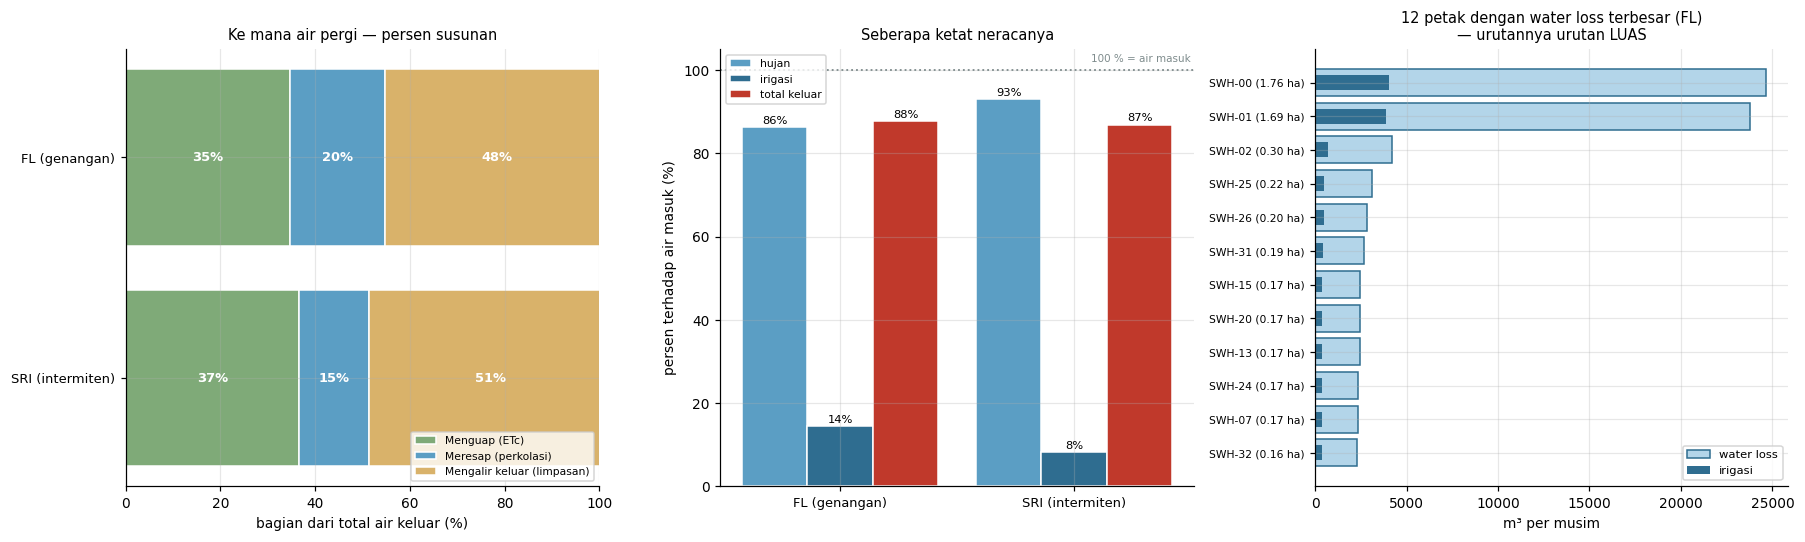

In [13]:
# ---------- gambar: susunan water loss + persen ----------
fig, axes = plt.subplots(1, 3, figsize=(16.5, 5.0))
WARNA = {"etc": "#7faa78", "perkolasi": "#5b9ec4", "limpasan": "#d9b26a"}
LBLK  = {"etc": "Menguap (ETc)", "perkolasi": "Meresap (perkolasi)",
         "limpasan": "Mengalir keluar (limpasan)"}

ax = axes[0]
kiri = np.zeros(len(REZIM))
for k in WARNA:
    v = np.array([AIR[AIR.rezim == rz][k+"_pct"].iloc[0] for rz in REZIM])
    ax.barh(range(len(REZIM)), v, left=kiri, color=WARNA[k], edgecolor="white",
            label=LBLK[k])
    for i, (val, l) in enumerate(zip(v, kiri)):
        if val > 4:
            ax.text(l + val/2, i, f"{val:.0f}%", ha="center", va="center", fontsize=8.5,
                    weight="bold", color="white")
    kiri += v
ax.set_yticks(range(len(REZIM)))
ax.set_yticklabels([REZIM[r]["nama"] for r in REZIM], fontsize=8.5)
ax.invert_yaxis(); ax.set_xlabel("bagian dari total air keluar (%)")
ax.set_title("Ke mana air pergi — persen susunan", fontsize=9.5)
ax.legend(fontsize=7, loc="lower right"); ax.set_aspect("auto"); ax.set_xlim(0, 100)

ax = axes[1]
x = np.arange(len(REZIM)); w = 0.28
for i, (k, lbl) in enumerate((("hujan_pct_masuk","hujan"),
                              ("irigasi_pct_masuk","irigasi"),
                              ("loss_pct_masuk","total keluar"))):
    v = [AIR[AIR.rezim == rz][k].iloc[0] for rz in REZIM]
    c = ["#5b9ec4", "#2f6d90", "#c0392b"][i]
    b = ax.bar(x + (i-1)*w, v, w, color=c, edgecolor="white", label=lbl)
    ax.bar_label(b, fmt="%.0f%%", fontsize=7.5, padding=1)
ax.axhline(100, color="#7f8c8d", ls=":", lw=1.2)
ax.text(len(REZIM)-0.5, 102, "100 % = air masuk", fontsize=6.8, color="#7f8c8d", ha="right")
ax.set_xticks(x); ax.set_xticklabels([REZIM[r]["nama"] for r in REZIM], fontsize=8.5)
ax.set_ylabel("persen terhadap air masuk (%)")
ax.set_title("Seberapa ketat neracanya", fontsize=9.5)
ax.legend(fontsize=7); ax.set_aspect("auto")

ax = axes[2]
d = AIR[AIR.rezim == "FL"].sort_values("water_loss_m3", ascending=False).head(12)
ax.barh(range(len(d)), d["water_loss_m3"], color="#b3d5e9", edgecolor="#2f6d90",
        label="water loss")
ax.barh(range(len(d)), d["irigasi_m3"], height=0.45, color="#2f6d90", label="irigasi")
ax.set_yticks(range(len(d)))
ax.set_yticklabels([f"{p} ({l:.2f} ha)" for p, l in zip(d["petak"], d["luas_ha"])],
                   fontsize=7)
ax.invert_yaxis(); ax.set_xlabel("m³ per musim")
ax.set_title("12 petak dengan water loss terbesar (FL)\n— urutannya urutan LUAS", fontsize=9.5)
ax.legend(fontsize=7.5); ax.set_aspect("auto")

plt.tight_layout()
simpan_gambar(fig, "05_water_loss_persen"); plt.show()

---
## 9. Angka mana yang paling menentukan?

Sebelum angka di atas dipakai, perlu jelas mana yang **layak dipercaya** dan mana yang
menggantung pada asumsi. Tiga masukan diuji satu-satu, dan yang dilihat adalah
pengaruhnya terhadap irigasi semusim.

Ini yang menentukan urutan kerja lapangan: yang paling berpengaruh diukur lebih dulu.

            SENSITIVITAS — pengaruh terhadap irigasi semusim (FL)

  perkolasi
    rentang diuji : 1 mm/hari .. 4 mm/hari
    irigasi       : 212 - 323 mm  -> rentang 112 mm (53 %)

  efisiensi jaringan
    rentang diuji : 0.50 .. 1.00
    irigasi       : 230 - 230 mm  -> rentang 0 mm (0 %)

  tahun (hujan nyata)
    rentang diuji : 2016 .. 2024
    irigasi       : 204 - 390 mm  -> rentang 186 mm (91 %)

--------------------------------------------------------------------------------
  URUTAN PENGARUH (terbesar dulu):
    1. tahun (hujan nyata)          186 mm
    2. perkolasi                    112 mm
    3. efisiensi jaringan             0 mm
--------------------------------------------------------------------------------
  Efisiensi jaringan tidak mengubah kebutuhan DI PETAK sama sekali - yang berubah
  adalah yang harus DIAMBIL di bendung: 230 - 461 mm. Itu soal saluran, bukan sawah.
--------------------------------------------------------------------------------
  ARTINYA UNTUK UR

[gambar] 06_sensitivitas.png                    108 KB


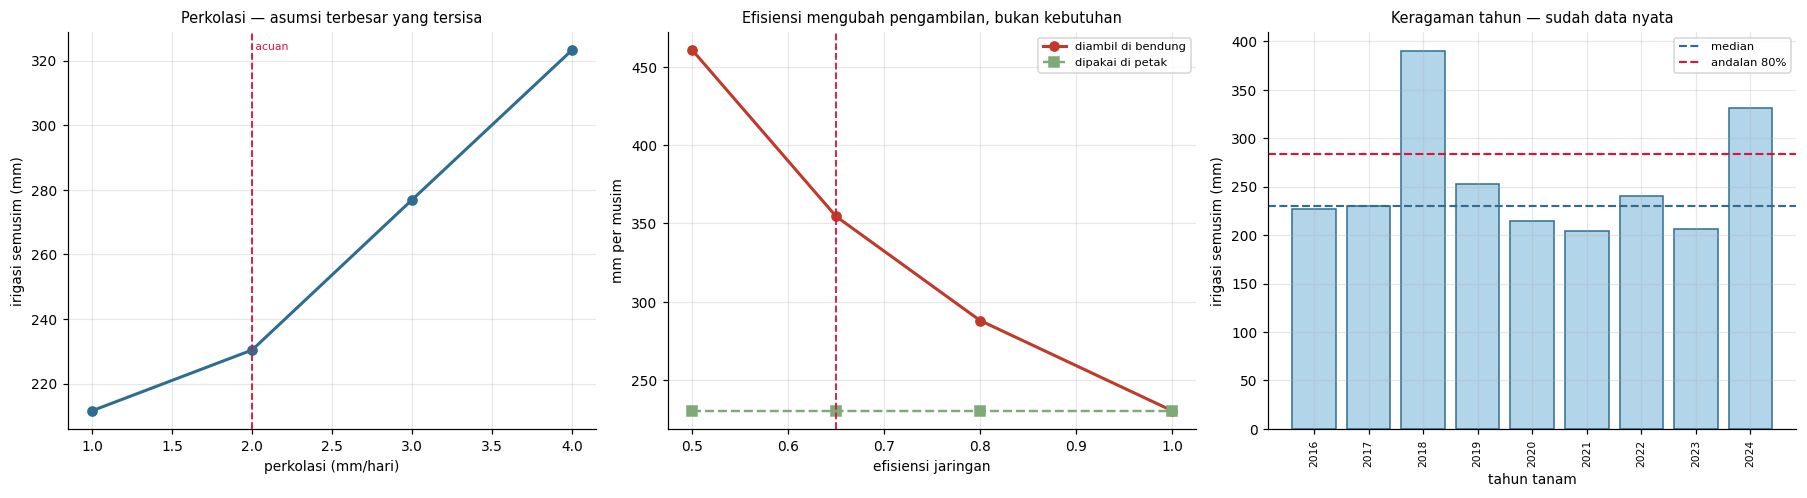

In [14]:
uji = []
for p in PERKOLASI_UJI:
    d = neraca_musim(date(STAT["FL"]["tahun_median"], BULAN_TANAM, 1), "FL", era, perkolasi=p)
    r = ringkas_musim(d)
    uji.append({"masukan": "perkolasi", "nilai": f"{p:.0f} mm/hari",
                "irigasi_mm": r["irigasi_mm"], "keluar_mm": r["keluar_mm"]})
for e in (0.50, 0.65, 0.80, 1.00):
    r = STAT["FL"]["median"]
    uji.append({"masukan": "efisiensi jaringan", "nilai": f"{e:.2f}",
                "irigasi_mm": r["irigasi_mm"], "keluar_mm": r["keluar_mm"],
                "pengambilan_mm": r["irigasi_mm"]/e})
for th in MUSIM[MUSIM.rezim == "FL"]["tahun_tanam"]:
    r = MUSIM[(MUSIM.rezim == "FL") & (MUSIM.tahun_tanam == th)].iloc[0]
    uji.append({"masukan": "tahun (hujan nyata)", "nilai": str(th),
                "irigasi_mm": r["irigasi_mm"], "keluar_mm": r["keluar_mm"]})
UJI = pd.DataFrame(uji)

print("=" * 80)
print("            SENSITIVITAS — pengaruh terhadap irigasi semusim (FL)")
print("=" * 80)
for m in UJI["masukan"].unique():
    d = UJI[UJI.masukan == m]
    lo, hi = d["irigasi_mm"].min(), d["irigasi_mm"].max()
    print(f"\n  {m}")
    print(f"    rentang diuji : {d['nilai'].iloc[0]} .. {d['nilai'].iloc[-1]}")
    print(f"    irigasi       : {lo:,.0f} - {hi:,.0f} mm  "
          f"-> rentang {hi-lo:,.0f} mm ({100*(hi-lo)/lo:.0f} %)")
print("\n" + "-" * 80)
rent = {m: (UJI[UJI.masukan==m]["irigasi_mm"].max() - UJI[UJI.masukan==m]["irigasi_mm"].min())
        for m in UJI["masukan"].unique()}
urut = sorted(rent, key=rent.get, reverse=True)
print("  URUTAN PENGARUH (terbesar dulu):")
for i, m in enumerate(urut, 1):
    print(f"    {i}. {m:<24}{rent[m]:>8,.0f} mm")
print("-" * 80)
print(f"  Efisiensi jaringan tidak mengubah kebutuhan DI PETAK sama sekali - yang berubah")
print(f"  adalah yang harus DIAMBIL di bendung: {UJI[UJI.masukan=='efisiensi jaringan']['pengambilan_mm'].min():,.0f}"
      f" - {UJI[UJI.masukan=='efisiensi jaringan']['pengambilan_mm'].max():,.0f} mm. "
      "Itu soal saluran, bukan sawah.")
print("-" * 80)
print("  ARTINYA UNTUK URUTAN KERJA LAPANGAN:")
print(f"    1. Yang paling menentukan sudah TERSEDIA sebagai data nyata (hujan 11 tahun),")
print(f"       jadi tidak perlu diukur - cukup dipakai lewat R80 dan musim andalan.")
print(f"    2. Yang paling berpengaruh dan MASIH TEBAKAN adalah perkolasi "
      f"({rent.get('perkolasi', 0):,.0f} mm).")
print(f"       Uji perkolasi satu petak per hamparan sudah cukup memangkas ketidakpastian")
print(f"       ini - jauh lebih murah daripada mengukur semua {N_PETAK} petak.")
print("=" * 80)

fig, axes = plt.subplots(1, 3, figsize=(16.5, 4.6))
ax = axes[0]
d = UJI[UJI.masukan == "perkolasi"]
ax.plot([float(v.split()[0]) for v in d["nilai"]], d["irigasi_mm"], "o-",
        color="#2f6d90", lw=2)
ax.axvline(PERKOLASI_MM, color="crimson", ls="--", lw=1.2)
ax.text(PERKOLASI_MM, d["irigasi_mm"].max(), " acuan", fontsize=7, color="crimson")
ax.set_xlabel("perkolasi (mm/hari)"); ax.set_ylabel("irigasi semusim (mm)")
ax.set_title("Perkolasi — asumsi terbesar yang tersisa", fontsize=9.5); ax.set_aspect("auto")

ax = axes[1]
d = UJI[UJI.masukan == "efisiensi jaringan"]
ax.plot([float(v) for v in d["nilai"]], d["pengambilan_mm"], "o-", color="#c0392b", lw=2,
        label="diambil di bendung")
ax.plot([float(v) for v in d["nilai"]], d["irigasi_mm"], "s--", color="#7faa78", lw=1.6,
        label="dipakai di petak")
ax.axvline(EFISIENSI_IRIGASI, color="crimson", ls="--", lw=1.2)
ax.set_xlabel("efisiensi jaringan"); ax.set_ylabel("mm per musim")
ax.set_title("Efisiensi mengubah pengambilan, bukan kebutuhan", fontsize=9.5)
ax.legend(fontsize=7.5); ax.set_aspect("auto")

ax = axes[2]
d = UJI[UJI.masukan == "tahun (hujan nyata)"]
ax.bar(d["nilai"], d["irigasi_mm"], color="#b3d5e9", edgecolor="#2f6d90")
ax.axhline(STAT["FL"]["median"]["irigasi_mm"], color="#2f6d90", ls="--", lw=1.4,
           label="median")
ax.axhline(STAT["FL"]["andalan"]["irigasi_mm"], color="crimson", ls="--", lw=1.4,
           label="andalan 80%")
ax.set_ylabel("irigasi semusim (mm)"); ax.set_xlabel("tahun tanam")
ax.tick_params(axis="x", rotation=90, labelsize=7)
ax.set_title("Keragaman tahun — sudah data nyata", fontsize=9.5)
ax.legend(fontsize=7.5); ax.set_aspect("auto")

plt.tight_layout()
simpan_gambar(fig, "06_sensitivitas"); plt.show()

---
## 10. Per hamparan — empat jaringan, bukan satu

Notebook terrain menemukan lokasi ini terdiri dari **4 hamparan** yang terpisah sampai
738 m dan berbeda tinggi sampai 14 m. Air tidak mengalir antar hamparan yang terpisah,
jadi kebutuhan dan debitnya harus dijumlahkan **per hamparan** — inilah angka yang
dipakai menakar sumber air masing-masing.

In [15]:
grup = (AIR[AIR.rezim == "FL"].groupby("hamparan")
        .agg(n_petak=("petak","count"), luas_ha=("luas_ha","sum"),
             irigasi_m3=("irigasi_m3","sum"), irigasi_m3_andalan=("irigasi_m3_andalan","sum"),
             debit_l_detik=("debit_l_detik","sum"),
             debit_l_detik_andalan=("debit_l_detik_andalan","sum"),
             water_loss_m3=("water_loss_m3","sum"),
             Q_isi_l_detik=("Q_isi_l_detik","sum"))
        .reset_index())
grup = grup.merge(HAM[["hamparan","elev_min","elev_maks","arah_hadap","terjun_m",
                       "tangkapan_keluar_ha"]], on="hamparan", how="left")
grup["debit_pl_l_detik"] = ke_l_detik_ha(IR_ACUAN)*grup["luas_ha"]
grup["giliran_isi"] = np.ceil(grup["Q_isi_l_detik"]/KAPASITAS_SALURAN)

print("=" * 86)
print("        KEBUTUHAN AIR PER HAMPARAN (rezim FL, musim tengahan)")
print("=" * 86)
print(f"  {'ham':<5}{'petak':>6}{'luas':>8}{'irigasi':>11}{'andalan':>11}"
      f"{'debit':>9}{'siap lahan':>12}{'water loss':>12}")
print(f"  {'':<5}{'':>6}{'(ha)':>8}{'(m3)':>11}{'(m3)':>11}{'(l/dt)':>9}{'(l/dt)':>12}{'(m3)':>12}")
print("-" * 86)
for _, r in grup.iterrows():
    print(f"  {r['hamparan']:<5}{r['n_petak']:>6}{r['luas_ha']:>8.2f}{r['irigasi_m3']:>11,.0f}"
          f"{r['irigasi_m3_andalan']:>11,.0f}{r['debit_l_detik']:>9.2f}"
          f"{r['debit_pl_l_detik']:>12.2f}{r['water_loss_m3']:>12,.0f}")
print("-" * 86)
print(f"  {'TOTAL':<5}{grup['n_petak'].sum():>6}{grup['luas_ha'].sum():>8.2f}"
      f"{grup['irigasi_m3'].sum():>11,.0f}{grup['irigasi_m3_andalan'].sum():>11,.0f}"
      f"{grup['debit_l_detik'].sum():>9.2f}{grup['debit_pl_l_detik'].sum():>12.2f}"
      f"{grup['water_loss_m3'].sum():>12,.0f}")
print("=" * 86)
print("  Yang harus dibaca dari tabel ini:")
print(f"  - Debit penyiapan lahan per hamparan {grup['debit_pl_l_detik'].min():.1f}-"
      f"{grup['debit_pl_l_detik'].max():.1f} l/detik. Inilah kapasitas yang harus tersedia")
print("    di tiap hamparan, dan tidak bisa saling menolong karena letaknya berjauhan.")
besar = grup.loc[grup["irigasi_m3"].idxmax()]
kecil = grup.loc[grup["irigasi_m3"].idxmin()]
print(f"  - {besar['hamparan']} paling besar ({besar['luas_ha']:.2f} ha, "
      f"{besar['irigasi_m3']:,.0f} m3), {kecil['hamparan']} paling kecil "
      f"({kecil['luas_ha']:.2f} ha, {kecil['irigasi_m3']:,.0f} m3).")
print(f"  - Hamparan yang daerah tangkapannya jauh lebih luas dari dirinya sendiri")
print(f"    MENERIMA aliran dari luar saat hujan (bagian 11 notebook terrain) - itu")
print(f"    berkah untuk pengairan tetapi risiko untuk galengan.")
print("=" * 86)
grup.round(2)

        KEBUTUHAN AIR PER HAMPARAN (rezim FL, musim tengahan)
  ham   petak    luas    irigasi    andalan    debit  siap lahan  water loss
                 (ha)       (m3)       (m3)   (l/dt)      (l/dt)        (m3)
--------------------------------------------------------------------------------------
  H1       13    3.21      7,395      9,106     0.94        6.61      45,065
  H2       26    2.78      6,395      7,875     0.81        5.72      38,975
  H3        1    1.69      3,899      4,801     0.50        3.48      23,761
  H4        1    0.01         29         36     0.00        0.03         179
--------------------------------------------------------------------------------------
  TOTAL    41    7.69     17,719     21,819     2.25       15.83     107,981
  Yang harus dibaca dari tabel ini:
  - Debit penyiapan lahan per hamparan 0.0-6.6 l/detik. Inilah kapasitas yang harus tersedia
    di tiap hamparan, dan tidak bisa saling menolong karena letaknya berjauhan.
  - H1 paling be

,hamparan,n_petak,luas_ha,irigasi_m3,irigasi_m3_andalan,debit_l_detik,debit_l_detik_andalan,water_loss_m3,Q_isi_l_detik,elev_min,elev_maks,arah_hadap,terjun_m,tangkapan_keluar_ha,debit_pl_l_detik,giliran_isi
0,H1,13,3.21,7394.89,9106.05,0.94,1.16,45065.49,121.03,696.76,705.00,T,8.24,6.94,6.61,3.0
1,H2,26,2.78,6395.44,7875.34,0.81,1.00,38974.73,104.68,687.91,695.30,T,7.40,83.37,5.72,3.0
2,H3,1,1.69,3899.06,4801.30,0.50,0.61,23761.43,63.82,697.00,699.99,TG,2.99,8.75,3.48,2.0
3,H4,1,0.01,29.36,36.16,0.00,0.00,178.93,0.48,703.90,704.43,BD,0.53,0.01,0.03,1.0


---
## 11. Peta per petak

Tiga peta yang sama bentuknya, berbeda isinya: volume irigasi, water loss, dan debit
pengisian. Semuanya **berbanding lurus dengan luas** — dan itu memang isi temuannya:
tanpa uji tanah, luas petak adalah satu-satunya pembeda yang sah.

Citra siap: 2048x2048 piksel | Citra: Esri, Maxar, Earthstar Geographics


[gambar] 07_peta_air_per_petak.png            1,208 KB


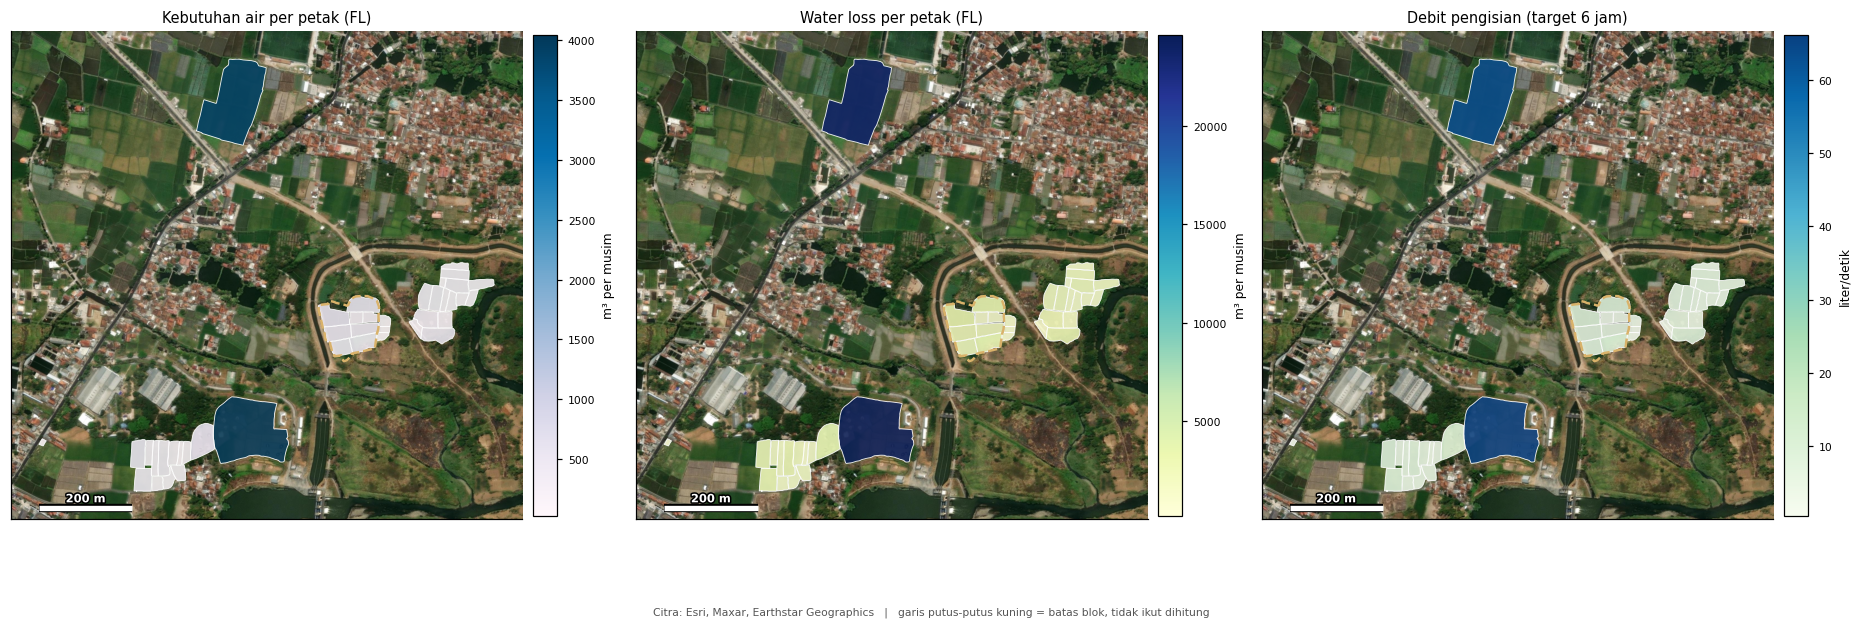

In [16]:
# ---------- geometri petak dari KML ----------
raw = KML.read_text(encoding="utf-8")
POLI = {}
for m in re.finditer(r"<Placemark[^>]*>(.*?)</Placemark>", raw, re.S):
    isi = m.group(1)
    nm = re.search(r"<name>(.*?)</name>", isi, re.S)
    nama = nm.group(1).strip() if nm else ""
    for cd in re.findall(r"<outerBoundaryIs>\s*<LinearRing>.*?<coordinates>(.*?)</coordinates>",
                         isi, re.S):
        t = [(float(x.split(",")[0]), float(x.split(",")[1]))
             for x in cd.split() if len(x.split(",")) >= 2]
        if len(t) >= 4:
            POLI[nama] = t

lat0, lon0 = LAT, LON
phi = math.radians(lat0)
M_LAT = 111_132.92 - 559.82*math.cos(2*phi) + 1.175*math.cos(4*phi)
M_LON = 111_412.84*math.cos(phi) - 93.5*math.cos(3*phi)
XY = {n: [((p[0]-lon0)*M_LON, (p[1]-lat0)*M_LAT) for p in t] for n, t in POLI.items()}
X_ALL = np.array([q[0] for t in XY.values() for q in t])
Y_ALL = np.array([q[1] for t in XY.values() for q in t])

# ---------- citra dari cache notebook ----------
TILE_URL = ("https://server.arcgisonline.com/ArcGIS/rest/services/"
            "World_Imagery/MapServer/tile/{z}/{y}/{x}")
KREDIT = "Citra: Esri, Maxar, Earthstar Geographics"

def piksel(lo, la, z):
    n = 256*2**z
    return ((lo+180)/360*n,
            (1 - math.log(math.tan(math.radians(la)) + 1/math.cos(math.radians(la)))/math.pi)/2*n)

def lonlat(px, py, z):
    n = 256*2**z
    return (px/n*360 - 180, math.degrees(math.atan(math.sinh(math.pi*(1 - 2*py/n)))))

def ambil_tile(z, x, y):
    f = TILE_DIR / f"{z}_{x}_{y}.jpg"
    if not f.exists():
        with urllib.request.urlopen(urllib.request.Request(TILE_URL.format(z=z, x=x, y=y),
                                                           headers=UA), timeout=25) as r:
            f.write_bytes(r.read())
    return np.asarray(Image.open(f).convert("RGB"))

def basemap(margin=60.0, z=ZOOM_PETA):
    lo0 = X_ALL.min()/M_LON + lon0 - margin/M_LON; la1 = Y_ALL.max()/M_LAT + lat0 + margin/M_LAT
    lo1 = X_ALL.max()/M_LON + lon0 + margin/M_LON; la0 = Y_ALL.min()/M_LAT + lat0 - margin/M_LAT
    px0, py0 = piksel(lo0, la1, z); px1, py1 = piksel(lo1, la0, z)
    tx0, ty0, tx1, ty1 = int(px0//256), int(py0//256), int(px1//256), int(py1//256)
    kan = np.zeros(((ty1-ty0+1)*256, (tx1-tx0+1)*256, 3), np.uint8)
    for ty in range(ty0, ty1+1):
        for tx in range(tx0, tx1+1):
            kan[(ty-ty0)*256:(ty-ty0+1)*256, (tx-tx0)*256:(tx-tx0+1)*256] = ambil_tile(z, tx, ty)
    lk, la_ = lonlat(tx0*256, ty0*256, z); lka, lb = lonlat((tx1+1)*256, (ty1+1)*256, z)
    return kan, [(lk-lon0)*M_LON, (lka-lon0)*M_LON, (lb-lat0)*M_LAT, (la_-lat0)*M_LAT]

try:
    socket.setdefaulttimeout(30)
    CITRA, EXT = basemap()
    print(f"Citra siap: {CITRA.shape[1]}x{CITRA.shape[0]} piksel | {KREDIT}")
except Exception as e:
    CITRA = EXT = None
    print(f"Citra tidak tersedia ({type(e).__name__}) - peta digambar tanpa latar.")

def peta_petak(ax, nilai, judul, satuan, cmap="PuBu"):
    if CITRA is not None:
        ax.imshow(CITRA, extent=EXT, origin="upper", interpolation="bilinear", zorder=0)
    else:
        ax.set_facecolor("#eaf4fa")
    vmin, vmax = float(nilai.min()), float(nilai.max())
    cm = plt.get_cmap(cmap)
    for n, v in nilai.items():
        if n not in XY:
            continue
        w = cm((v-vmin)/(vmax-vmin) if vmax > vmin else 0.5)
        ax.add_patch(MplPolygon(XY[n], closed=True, facecolor=w, alpha=0.88,
                                edgecolor="white", lw=0.6, zorder=3))
    for n in BLOK:
        if n in XY:
            ax.add_patch(MplPolygon(XY[n], closed=True, facecolor="none", edgecolor="#d9b26a",
                                    lw=1.6, ls="--", zorder=4))
    sm = plt.cm.ScalarMappable(cmap=cm, norm=plt.Normalize(vmin, vmax))
    cb = plt.colorbar(sm, ax=ax, fraction=0.044, pad=0.02)
    cb.set_label(satuan, fontsize=8); cb.ax.tick_params(labelsize=7)
    mg = 60
    ax.set_xlim(X_ALL.min()-mg, X_ALL.max()+mg); ax.set_ylim(Y_ALL.min()-mg, Y_ALL.max()+mg)
    ax.set_aspect("equal"); ax.set_title(judul, fontsize=9.5)
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
    x0, y0 = X_ALL.min(), Y_ALL.min()-mg*0.6
    ax.plot([x0, x0+200], [y0, y0], color="white", lw=3.5, solid_capstyle="butt",
            path_effects=[pe.withStroke(linewidth=5.5, foreground="black")], zorder=9)
    ax.text(x0+100, y0+8, "200 m", ha="center", va="bottom", fontsize=7.5, color="white",
            weight="bold", zorder=9, path_effects=[pe.withStroke(linewidth=2, foreground="black")])

fig, axes = plt.subplots(1, 3, figsize=(17.0, 6.2))
peta_petak(axes[0], FL["irigasi_m3"], "Kebutuhan air per petak (FL)", "m³ per musim", "PuBu")
peta_petak(axes[1], FL["water_loss_m3"], "Water loss per petak (FL)", "m³ per musim", "YlGnBu")
peta_petak(axes[2], FL["Q_isi_l_detik"],
           f"Debit pengisian (target {LAMA_ISI_JAM:.0f} jam)", "liter/detik", "GnBu")
fig.text(0.5, 0.02, (KREDIT if CITRA is not None else "(tanpa citra satelit)") +
         "   |   garis putus-putus kuning = batas blok, tidak ikut dihitung",
         ha="center", fontsize=7, color="#555")
plt.tight_layout(rect=[0, 0.035, 1, 1])
simpan_gambar(fig, "07_peta_air_per_petak"); plt.show()

---
## 12. Ekspor hasil

Keluaran ke `note/output-swh-jb-grt-air/`:

| Berkas | Isi |
|---|---|
| `kebutuhan_air_petak.csv` | **satu baris per petak per rezim** — luas, kebutuhan air, debit, water loss beserta persennya |
| `ringkasan_air.csv` | satu baris angka pokok seluruh lokasi |
| `ringkasan_air_hamparan.csv` | per hamparan — untuk menakar sumber air masing-masing |
| `neraca_musim.csv` | 22 musim (11 tahun × 2 rezim) — sebaran antar-tahun |
| `neraca_harian_musim_tengahan.csv` | neraca harian musim tengahan, kedua rezim |
| `pindai_tanggal_tanam.csv` | irigasi semusim untuk 12 bulan tanam |
| `sensitivitas.csv` | pengaruh perkolasi, efisiensi, dan tahun |
| `petak_kebutuhan_air.kml` | petak diwarnai kebutuhan air — dibuka di Google Earth |
| `gambar/*.png` | semua gambar di atas |

`kebutuhan_air_petak.csv` inilah yang dibaca halaman web `web-app/`.

In [17]:
AIR.round(6).to_csv(OUT_DIR / "kebutuhan_air_petak.csv", index=False)
MUSIM.round(4).to_csv(OUT_DIR / "neraca_musim.csv", index=False)
PINDAI.round(2).to_csv(OUT_DIR / "pindai_tanggal_tanam.csv", index=False)
UJI.round(3).to_csv(OUT_DIR / "sensitivitas.csv", index=False)
grup.round(4).to_csv(OUT_DIR / "ringkasan_air_hamparan.csv", index=False)

harian_gab = []
for rz in REZIM:
    d = musim_harian[(rz, STAT[rz]["tahun_median"])].copy()
    d.insert(0, "rezim", rz); d.insert(1, "tahun_tanam", STAT[rz]["tahun_median"])
    harian_gab.append(d)
hg = pd.concat(harian_gab, ignore_index=True)
num = hg.select_dtypes(include="number").columns        # round() hanya untuk kolom angka
hg[num] = hg[num].round(4)
hg.to_csv(OUT_DIR / "neraca_harian_musim_tengahan.csv", index=False)

fl0 = AIR[AIR.rezim == "FL"].iloc[0]
ringkas = {
    "berkas_kml": KML.name, "sumber_terrain": DIR_TER.name,
    "lat_pusat": round(LAT, 6), "lon_pusat": round(LON, 6),
    "elevasi_acuan_m": round(ELEVASI, 1),
    "n_petak": N_PETAK, "n_hamparan": int(HAM.shape[0]),
    "luas_petak_ha": round(LUAS_HA, 4), "luas_petak_m2": round(LUAS_M2, 1),
    "tahun_cuaca": f"{TAHUN_AWAL}-{TAHUN_AKHIR}", "n_musim": N_MUSIM_JALAN,
    "sumber_cuaca": "Open-Meteo ERA5-Land + NASA POWER",
    "hujan_tahunan_rata_mm": round(float(RRAT.sum()), 0),
    # dua besaran berbeda - lihat bagian 3; jangan ditukar
    "jumlah_r80_periode_mm": round(float(R80.sum()), 0),
    "hujan_tahunan_andalan_mm": round(r80_tahunan, 0),
    "eto_rata_mm_hari": round(ETO_RATA, 3),
    "metode_eto": "FAO-56 Penman-Monteith",
    "bulan_tanam": NB[BULAN_TANAM-1], "hari_musim": N_HARI_MUSIM,
    "perkolasi_mm_hari": PERKOLASI_MM, "efisiensi_jaringan": EFISIENSI_IRIGASI,
    "rezim_utama": "FL",
    "irigasi_mm": round(fl0["irigasi_mm"], 1),
    "irigasi_m3": round(float(FL["irigasi_m3"].sum()), 1),
    "irigasi_mm_andalan": round(fl0["irigasi_mm_andalan"], 1),
    "irigasi_m3_andalan": round(float(FL["irigasi_m3_andalan"].sum()), 1),
    "debit_l_detik": round(float(FL["debit_l_detik"].sum()), 3),
    "debit_l_detik_andalan": round(float(FL["debit_l_detik_andalan"].sum()), 3),
    "debit_siap_lahan_l_detik": round(float(ke_l_detik_ha(IR_ACUAN)*LUAS_HA), 3),
    "water_loss_m3": round(float(FL["water_loss_m3"].sum()), 1),
    "keluar_mm": round(fl0["keluar_mm"], 1),
    "etc_pct": round(fl0["etc_pct"], 2),
    "perkolasi_pct": round(fl0["perkolasi_pct"], 2),
    "limpasan_pct": round(fl0["limpasan_pct"], 2),
    "loss_pct_masuk": round(fl0["loss_pct_masuk"], 2),
    "hujan_mm": round(fl0["hujan_mm"], 1), "masuk_mm": round(fl0["masuk_mm"], 1),
}
for rz in REZIM:
    d = AIR[AIR.rezim == rz].iloc[0]
    ringkas[f"irigasi_mm_{rz}"] = round(d["irigasi_mm"], 1)
    ringkas[f"keluar_mm_{rz}"] = round(d["keluar_mm"], 1)
df_ringkas = pd.DataFrame([ringkas])
df_ringkas.to_csv(OUT_DIR / "ringkasan_air.csv", index=False)

# ---------- KML: petak diwarnai kebutuhan air ----------
def warna_kml(frac):
    """Skala biru KML (aabbggrr) dari 0..1."""
    c = plt.get_cmap("PuBu")(0.15 + 0.8*frac)
    r, g, b = [int(255*v) for v in c[:3]]
    return f"c8{b:02x}{g:02x}{r:02x}"

vmin, vmax = FL["irigasi_m3"].min(), FL["irigasi_m3"].max()
pot = ['<?xml version="1.0" encoding="UTF-8"?>',
       '<kml xmlns="http://www.opengis.net/kml/2.2"><Document>',
       f'<name>Kebutuhan air per petak - {KML.stem} (FL, tanam {NB[BULAN_TANAM-1]})</name>']
for n, r in FL.iterrows():
    if n not in POLI:
        continue
    frac = (r["irigasi_m3"]-vmin)/(vmax-vmin) if vmax > vmin else 0.5
    gaya = f"g{abs(hash(n)) % 100000}"
    pot.append(f'<Style id="{gaya}"><LineStyle><color>ffffffff</color><width>1.2</width>'
               f'</LineStyle><PolyStyle><color>{warna_kml(frac)}</color></PolyStyle></Style>')
    koord = " ".join(f"{a:.7f},{b:.7f},0" for a, b in POLI[n] + [POLI[n][0]])
    ket = (f"hamparan {r['hamparan']} | luas {r['luas_ha']:.4f} ha<br/>"
           f"<b>Kebutuhan air</b> {r['irigasi_m3']:,.0f} m3 "
           f"({r['irigasi_mm']:,.0f} mm)<br/>"
           f"andalan 80% {r['irigasi_m3_andalan']:,.0f} m3<br/>"
           f"debit {r['debit_l_detik']:.3f} l/detik | pengisian "
           f"{r['Q_isi_l_detik']:.1f} l/detik (pintu {r['diameter_cm']:.0f} cm)<br/>"
           f"<b>Water loss</b> {r['water_loss_m3']:,.0f} m3 ({r['keluar_mm']:,.0f} mm)<br/>"
           f"menguap {r['etc_pct']:.0f} % | meresap {r['perkolasi_pct']:.0f} % | "
           f"mengalir keluar {r['limpasan_pct']:.0f} %<br/>"
           f"total keluar {r['loss_pct_masuk']:.0f} % dari air masuk")
    pot.append(f'<Placemark><name>{n}</name><description><![CDATA[{ket}]]></description>'
               f'<styleUrl>#{gaya}</styleUrl><Polygon><outerBoundaryIs><LinearRing>'
               f'<tessellate>1</tessellate><coordinates>{koord}</coordinates>'
               f'</LinearRing></outerBoundaryIs></Polygon></Placemark>')
pot.append('</Document></kml>')
(OUT_DIR / "petak_kebutuhan_air.kml").write_text("\n".join(pot), encoding="utf-8")

print("Tersimpan:")
for f in sorted(OUT_DIR.glob("*")):
    if f.is_file():
        print(f"  {f.name:<38} {f.stat().st_size/1024:>9,.1f} KB")
print(f"  cuaca/  ({len(list(CUACA_DIR.glob('*')))} berkas JSON mentah)")
print(f"  gambar/ ({len(GAMBAR_TERSIMPAN)} berkas PNG)")
df_ringkas.T.rename(columns={0: "nilai"})

Tersimpan:
  kebutuhan_air_petak.csv                     30.4 KB
  neraca_harian_musim_tengahan.csv            22.4 KB
  neraca_musim.csv                             2.3 KB
  petak_kebutuhan_air.kml                     73.9 KB
  pindai_tanggal_tanam.csv                     0.7 KB
  ringkasan_air.csv                            0.9 KB
  ringkasan_air_hamparan.csv                   0.6 KB
  sensitivitas.csv                             0.8 KB
  cuaca/  (2 berkas JSON mentah)
  gambar/ (7 berkas PNG)


,nilai
berkas_kml,SWH-JB-GRT.kml
sumber_terrain,output-swh-jb-grt
lat_pusat,-7.186194
lon_pusat,107.911566
elevasi_acuan_m,696.5
n_petak,41
n_hamparan,4
luas_petak_ha,7.691
luas_petak_m2,76909.6
tahun_cuaca,2015-2025


In [18]:
print("=" * 84)
print(f"   RINGKASAN AIR — {KML.stem}   ({N_PETAK} petak, {LUAS_HA:.2f} ha, "
      f"tanam {NB[BULAN_TANAM-1]})")
print("=" * 84)
print(f"  Cuaca         : {TAHUN_AWAL}-{TAHUN_AKHIR} ({TAHUN_AKHIR-TAHUN_AWAL+1} tahun harian, "
      f"{N_MUSIM_JALAN} musim lengkap) dari ERA5-Land + NASA POWER — data nyata")
print(f"                  hujan {RRAT.sum():,.0f} mm/tahun (andalan {r80_tahunan:,.0f} mm) | "
      f"ETo {ETO_RATA:.2f} mm/hari (FAO-56)")
print("-" * 84)
for rz in REZIM:
    d = AIR[AIR.rezim == rz]; d0 = d.iloc[0]
    print(f"  {REZIM[rz]['nama']:<18}")
    print(f"    Kebutuhan air : {d0['irigasi_mm']:>7,.0f} mm = {d['irigasi_m3'].sum():>8,.0f} m3"
          f"   (andalan {d0['irigasi_mm_andalan']:,.0f} mm = "
          f"{d['irigasi_m3_andalan'].sum():,.0f} m3)")
    print(f"    Debit         : {d['debit_l_detik'].sum():>7.2f} l/detik rata-rata"
          f"   ({d['debit_l_detik'].sum()/LUAS_HA:.2f} l/detik/ha)")
    print(f"    Water loss    : {d0['keluar_mm']:>7,.0f} mm = {d['water_loss_m3'].sum():>8,.0f} m3"
          f"   = {d0['loss_pct_masuk']:.0f} % dari air masuk")
    print(f"      menguap {d0['etc_pct']:.0f} %  |  meresap {d0['perkolasi_pct']:.0f} %  |  "
          f"mengalir keluar {d0['limpasan_pct']:.1f} %")
print("-" * 84)
print(f"  Debit penyiapan lahan : {ke_l_detik_ha(IR_ACUAN)*LUAS_HA:.2f} l/detik "
      f"({IR_ACUAN:.1f} mm/hari selama {LAMA_SIAP_LAHAN} hari)")
print(f"    -> {ke_l_detik_ha(IR_ACUAN)*LUAS_HA/FL['debit_l_detik'].sum():.1f}x debit fase "
      f"tumbuh. INI yang menentukan kapasitas saluran.")
print(f"  Pintu petak           : {FL['diameter_cm'].min():.0f}-{FL['diameter_cm'].max():.0f} cm "
      f"untuk pengisian {LAMA_ISI_JAM:.0f} jam")
print("=" * 84)
print("  YANG BOLEH DAN TIDAK BOLEH DIPAKAI")
print("=" * 84)
print("  BOLEH:")
print(f"    - Volume dan debit per petak (m3, l/detik) - luas dari KML sudah teruji,")
print(f"      cuaca data nyata {TAHUN_AKHIR-TAHUN_AWAL+1} tahun ({N_MUSIM_JALAN} musim lengkap disimulasikan),")
print(f"      dan ETo tervalidasi terhadap hitungan FAO-56 independen.")
print(f"    - Angka per hamparan untuk menakar sumber air tiap hamparan.")
_ur = sorted((("menguap", fl0["etc_pct"]), ("meresap", fl0["perkolasi_pct"]),
              ("mengalir keluar", fl0["limpasan_pct"])), key=lambda t: -t[1])
print(f"    - Urutan besaran water loss: " +
      " > ".join(f"{n} {v:.0f} %" for n, v in _ur) + ".")
print(f"      Yang terbesar ({_ur[0][0]}) datang dari hujan berlebih, jadi bukan")
print(f"      pemborosan jaringan - lihat catatan di bagian 8.")
print("  BELUM BOLEH:")
print(f"    - Membanding-bandingkan petak: mm-nya sama semua karena tanah belum diukur.")
print(f"    - Angka pasti perkolasi: masih asumsi KP-01 {PERKOLASI_MM:.0f} mm/hari, dan")
print(f"      inilah asumsi berpengaruh terbesar yang tersisa (bagian 9).")
print(f"    - Elevasi ambang pintu dan dimensi saluran: perlu ukur lapangan, bukan DEM.")
print(f"    - {', '.join(raksasa) if raksasa else '-'}: angkanya total blok, bukan satu petak.")
print("=" * 84)

   RINGKASAN AIR — SWH-JB-GRT   (41 petak, 7.69 ha, tanam Jan)
  Cuaca         : 2015-2025 (11 tahun harian, 9 musim lengkap) dari ERA5-Land + NASA POWER — data nyata
                  hujan 2,450 mm/tahun (andalan 1,915 mm) | ETo 3.45 mm/hari (FAO-56)
------------------------------------------------------------------------------------
  FL (genangan)     
    Kebutuhan air :     230 mm =   17,719 m3   (andalan 284 mm = 21,819 m3)
    Debit         :    2.25 l/detik rata-rata   (0.29 l/detik/ha)
    Water loss    :   1,404 mm =  107,981 m3   = 88 % dari air masuk
      menguap 35 %  |  meresap 20 %  |  mengalir keluar 47.6 %
  SRI (intermiten)  
    Kebutuhan air :     123 mm =    9,435 m3   (andalan 184 mm = 14,128 m3)
    Debit         :    1.20 l/detik rata-rata   (0.16 l/detik/ha)
    Water loss    :   1,289 mm =   99,135 m3   = 87 % dari air masuk
      menguap 37 %  |  meresap 15 %  |  mengalir keluar 51.0 %
------------------------------------------------------------------------

---
## 13. Asumsi, batasan, dan urutan kerja berikutnya

### Yang dihitung dari data nyata, bukan diasumsikan

- **Luas tiap petak** — dari `SWH-JB-GRT.kml`, sudah diperiksa tumpang tindihnya di
  notebook terrain (batas blok dibuang supaya tidak terhitung dua kali).
- **Cuaca harian 11 tahun** — ERA5-Land dan NASA POWER, diunduh penuh dan disimpan mentah.
- **ETo** — FAO-56 Penman-Monteith dihitung di notebook ini, dan hasilnya diuji terhadap
  hitungan FAO-56 independen milik Open-Meteo.
- **Hujan andalan R80** dan keragaman antar-tahun — dari sebaran 11 tahun.
- **Tanggal tanam** — dipilih dengan memindai 12 bulan, bukan ditebak.

### Asumsi yang dipakai, dengan arah galatnya

| Asumsi | Nilai | Kalau salah, ke mana galatnya |
|---|---|---|
| Perkolasi seragam | 2,0 mm/hari (KP-01) | **asumsi terbesar yang tersisa**; 1→4 mm/hari mengubah irigasi ratusan mm. Sawah lama biasanya membentuk lapisan kedap → nilai rendah lebih mungkin, jadi angka di sini cenderung **melebih** |
| Efisiensi jaringan | 0,65 (KP-01) | hanya mengubah pengambilan di bendung, tidak mengubah kebutuhan di petak. Pada saluran tanah, sebagian "kehilangan" sebenarnya terpakai lagi di petak bawah → 0,65 cenderung **melebihkan** pengambilan |
| Kc Arif et al. (2015) | 1,01–1,09 | dari sawah Indonesia, lebih rendah dari FAO-56. Memakai FAO-56 akan melebihkan ETc ~10 % |
| Air penjenuhan S | 250 mm (KP-01) | memengaruhi puncak penyiapan lahan, bukan total musim |
| Aturan genangan & lubang buang | dari `note-swh.ipynb` | menentukan besarnya limpasan; kalau lubang buang lebih rendah, limpasan naik |
| Hujan efektif 0,7 R80 | KP-01 | pada lahan 4,5 % yang landai, faktor ini wajar; di lahan curam terlalu murah hati |
| Semua petak bersifat sama | — | mm identik antar petak. Yang membedakan di lapangan adalah tanah, dan tanah belum diukur |

### Batasan yang harus disebut saat mengutip

1. **mm per petak identik.** Bukan hasil pengukuran per petak, melainkan angka standar
   dikalikan luas. Sah untuk volume dan debit; tidak sah untuk membandingkan petak.
2. **Dua poligon raksasa** (lihat bagian 0) sebenarnya blok yang belum dibagi petak.
   Angkanya benar sebagai total blok, tetapi bukan kebutuhan "satu petak".
3. **Hujan grid, bukan hujan lokasi.** Kedua sumber berbeda belasan persen di hujan
   tahunan. Itu sebabnya rancangan memakai R80 dan musim andalan, bukan satu tahun.
4. **Satu musim per tahun.** Notebook ini menghitung satu musim tanam; pola dua atau tiga
   kali tanam setahun belum ditinjau.
5. **Tidak ada hidraulika saluran.** Diameter pintu hanya patokan orifice; kehilangan
   tekanan, sedimentasi, dan elevasi ambang tidak dihitung.

### Urutan kerja berikutnya, menurut nilai per usaha

1. **Uji perkolasi — satu petak per hamparan (4 uji).** Ini asumsi berpengaruh terbesar
   yang tersisa. Caranya sederhana: genangi petak sampai tinggi tertentu, tutup pintu
   masuk dan buang, lalu ukur turunnya muka air tiap hari dengan penggaris yang
   dipatok. Turun total dikurangi penguapan (≈ETo hari itu) = perkolasi. Empat uji sudah
   memangkas ketidakpastian ini jauh lebih murah daripada mengukur 41 petak.
2. **Bagi dua poligon raksasa menjadi petak** di KML, mengikuti galengan yang sudah
   terlihat di citra. Tanpa ini, 45 % luas tidak punya angka per petak.
3. **Ukur elevasi titik masuk dan keluar tiap hamparan** — menggantikan tinggi terjun
   dari DEM, supaya ambang pintu bisa dirancang.
4. **Pastikan sumber air tiap hamparan.** Empat hamparan yang berjauhan tidak mungkin
   dilayani satu jaringan gravitasi; harus jelas mana dari mata air, saluran, atau embung.
5. **Catat hujan di lokasi** (satu penakar sederhana per hamparan). Setelah satu musim,
   hujan grid bisa dikoreksi dan seluruh hitungan ini menajam.